# Hybrid Student Project Recommendation System
## Training Pipeline with Research Areas and Enhanced Features

This notebook implements a hybrid recommendation system combining:
1. **Content-Based Filtering** (skill/interest/research matching)
2. **Collaborative Filtering** (peer behavior via SVD)
3. **XGBoost Ranker** (learned ranking with enhanced features)

### New Features:
- Research area alignment
- Research tags similarity
- Tech stack compatibility
- Career alignment score

In [1]:
import os
os.makedirs(r"C:\kb\student project\model", exist_ok=True)
os.makedirs(r"C:\kb\student project\plots", exist_ok=True)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import xgboost as xgb
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

PLOTS_DIR = r"C:\kb\student project\plots"

def save_plot(filename):
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, bbox_inches='tight', facecolor='white')
    print(f"  Saved: {filepath}")
    plt.show()

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

In [2]:
students = pd.read_csv(r"C:\kb\student project\dataset\students.csv")
projects = pd.read_csv(r"C:\kb\student project\dataset\projects.csv")
history = pd.read_csv(r"C:\kb\student project\dataset\history.csv")

print(f"Students: {students.shape}")
print(f"Projects: {projects.shape}")
print(f"History: {history.shape}")

# Display new columns
print("\nProject columns:", projects.columns.tolist())
print("\nSample research_area:", projects['research_area'].unique()[:5])
print("Sample research_tags:", projects['research_tags'].iloc[0])

Students: (500, 12)
Projects: (1628, 12)
History: (1035, 7)

Project columns: ['project_id', 'title', 'description', 'category', 'department', 'difficulty', 'required_skills', 'tech_stack', 'research_area', 'research_tags', 'avg_grade_given', 'times_selected']

Sample research_area: ['Artificial Intelligence' 'Computer Vision' 'Natural Language Processing'
 'Cybersecurity' 'Software Engineering']
Sample research_tags: classification, comparative, feature engineering, machine learning, neural networks, python programming


## 2. Exploratory Data Analysis

  Saved: C:\kb\student project\plots\01_dataset_overview.png


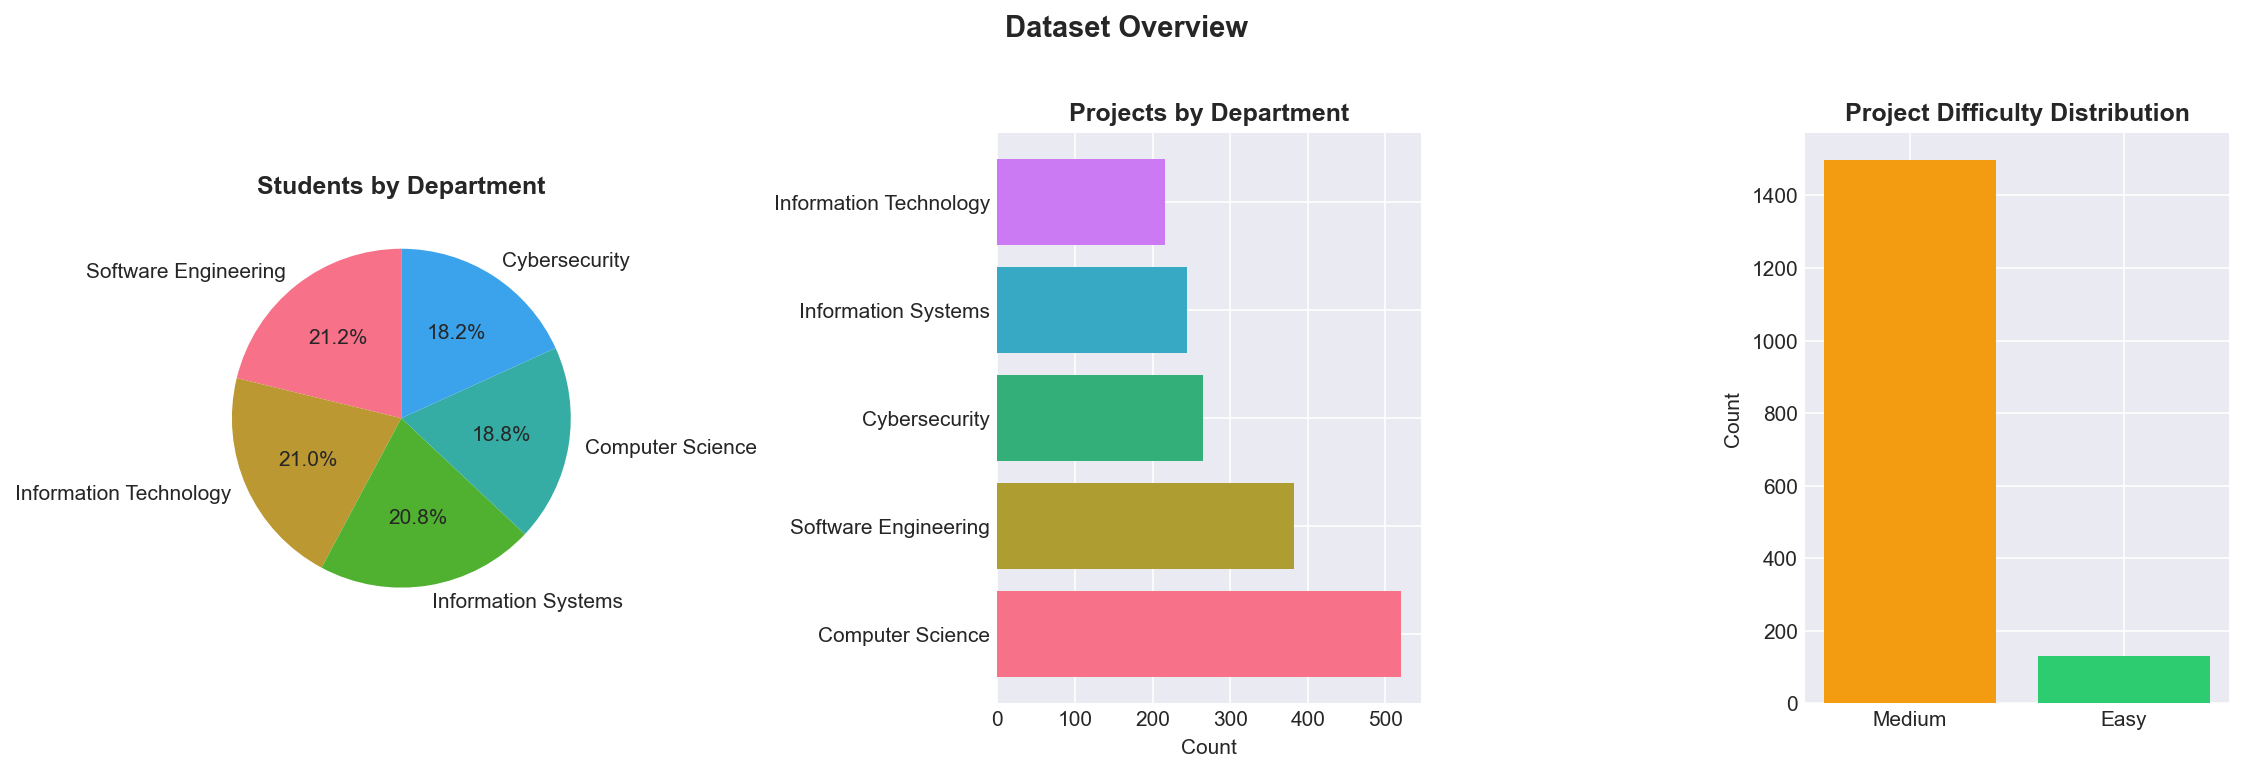

In [3]:
# Plot 1: Dataset Overview
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dept_counts = students['department'].value_counts()
axes[0].pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Students by Department', fontsize=12, fontweight='bold')

proj_dept = projects['department'].value_counts()
axes[1].barh(proj_dept.index, proj_dept.values, color=sns.color_palette("husl", len(proj_dept)))
axes[1].set_title('Projects by Department', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

complexity_counts = projects['difficulty'].value_counts()
colors = {'Easy': '#2ecc71', 'Medium': '#f39c12', 'Hard': '#e74c3c'}
axes[2].bar(complexity_counts.index, complexity_counts.values,
            color=[colors.get(x, '#95a5a6') for x in complexity_counts.index])
axes[2].set_title('Project Difficulty Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('01_dataset_overview.png')

  Saved: C:\kb\student project\plots\02_research_areas.png


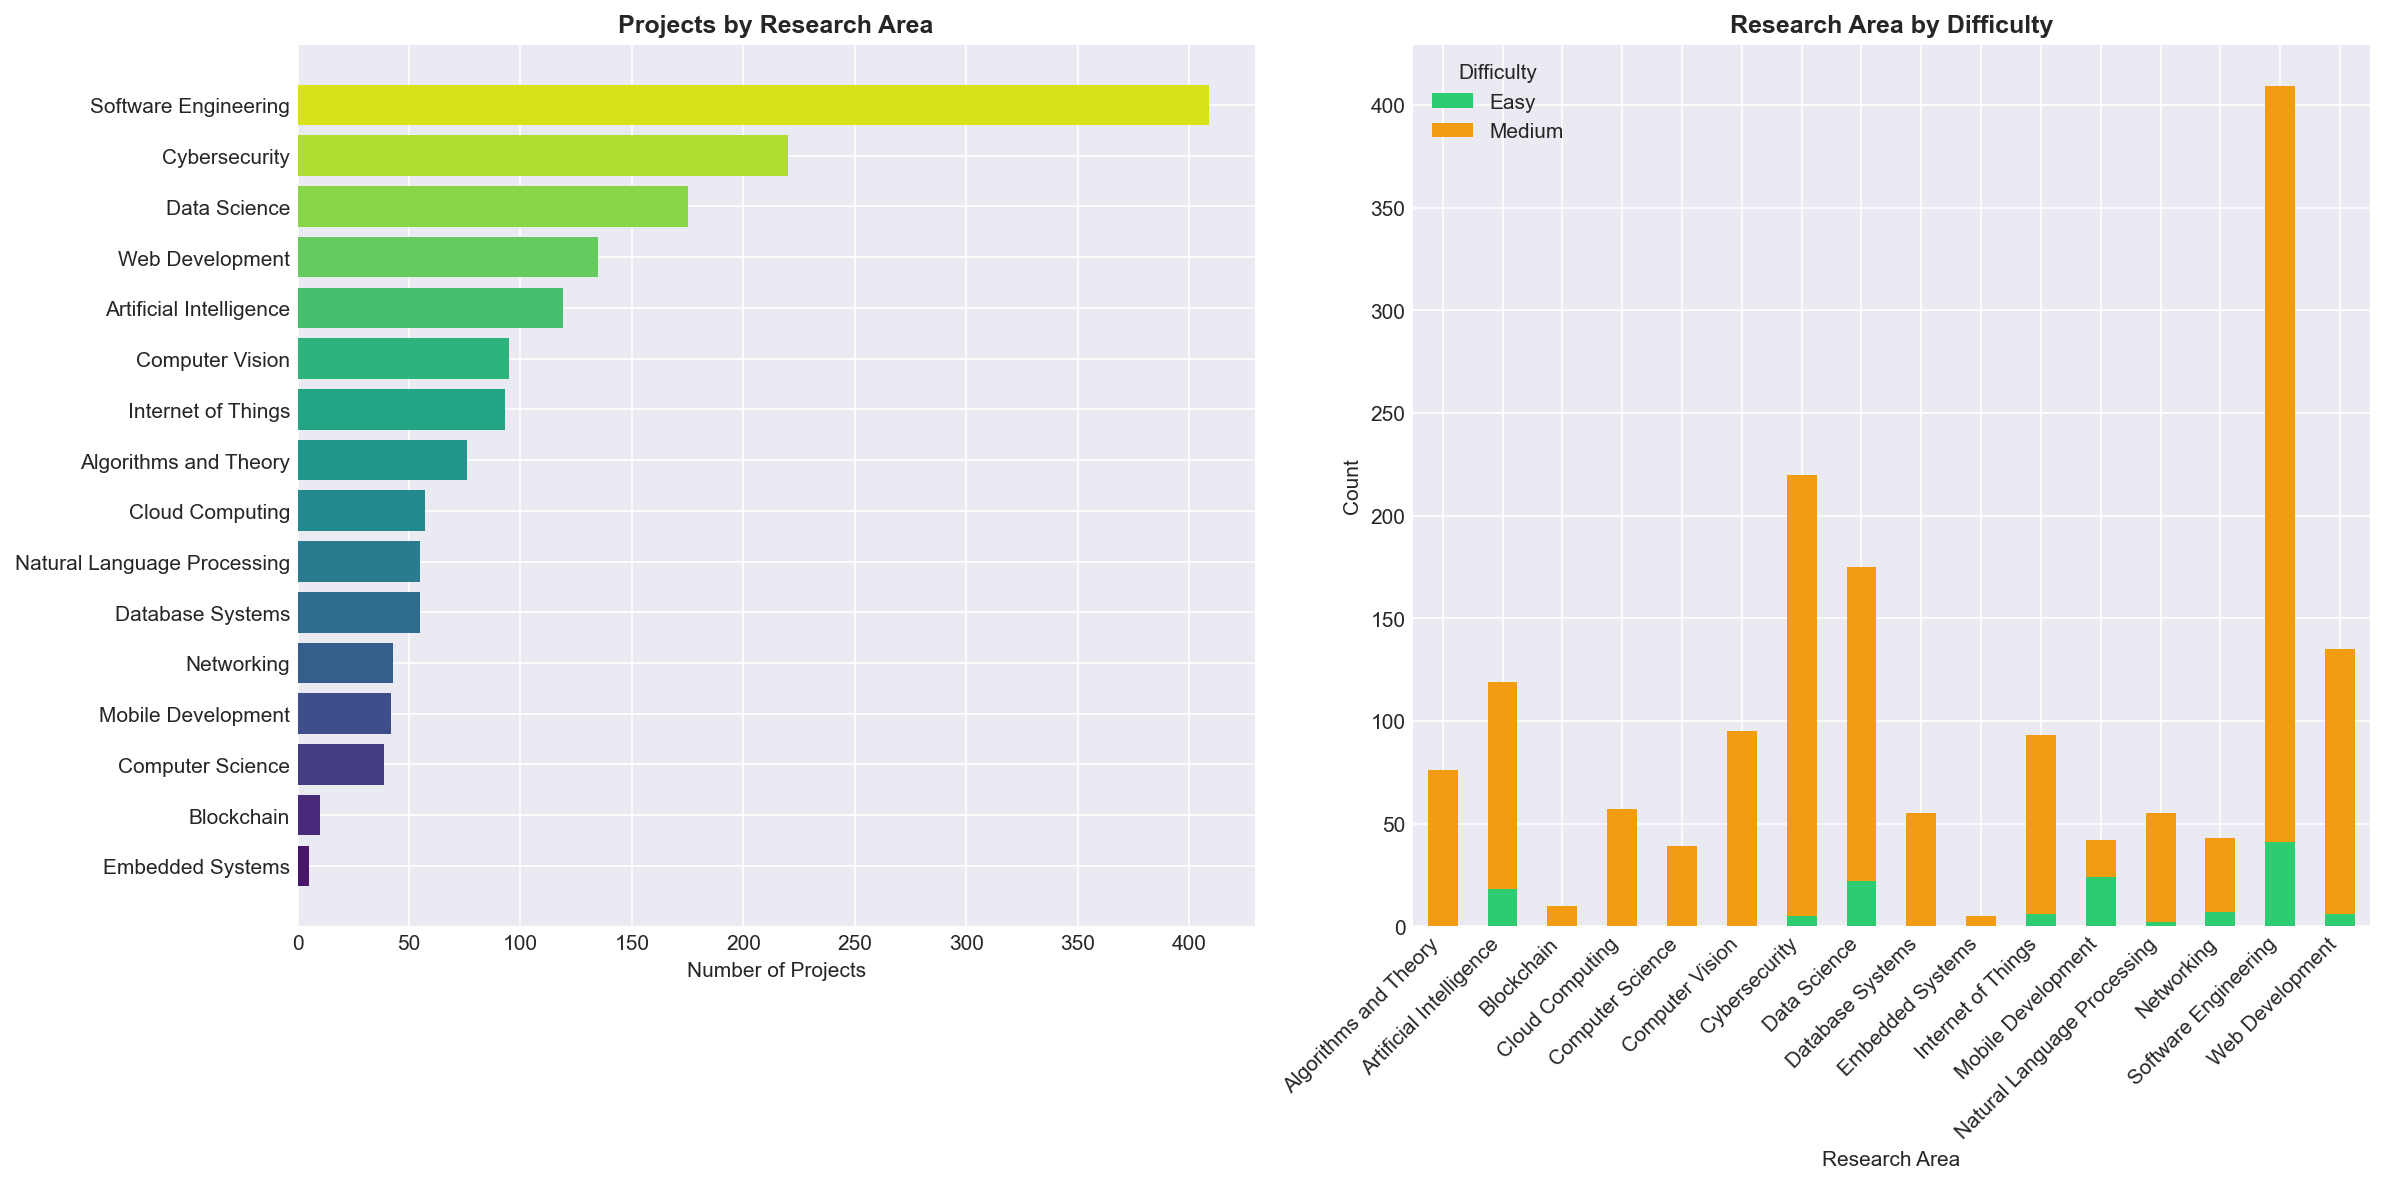

In [4]:
# Plot 2: Research Area Distribution (NEW)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

research_area_counts = projects['research_area'].value_counts()
axes[0].barh(research_area_counts.index[::-1], research_area_counts.values[::-1], 
             color=sns.color_palette("viridis", len(research_area_counts)))
axes[0].set_title('Projects by Research Area', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Projects')

# Research area by difficulty
research_diff = pd.crosstab(projects['research_area'], projects['difficulty'])
research_diff.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Research Area by Difficulty', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Research Area')
axes[1].set_ylabel('Count')
axes[1].legend(title='Difficulty')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
save_plot('02_research_areas.png')

  Saved: C:\kb\student project\plots\03_student_demographics.png


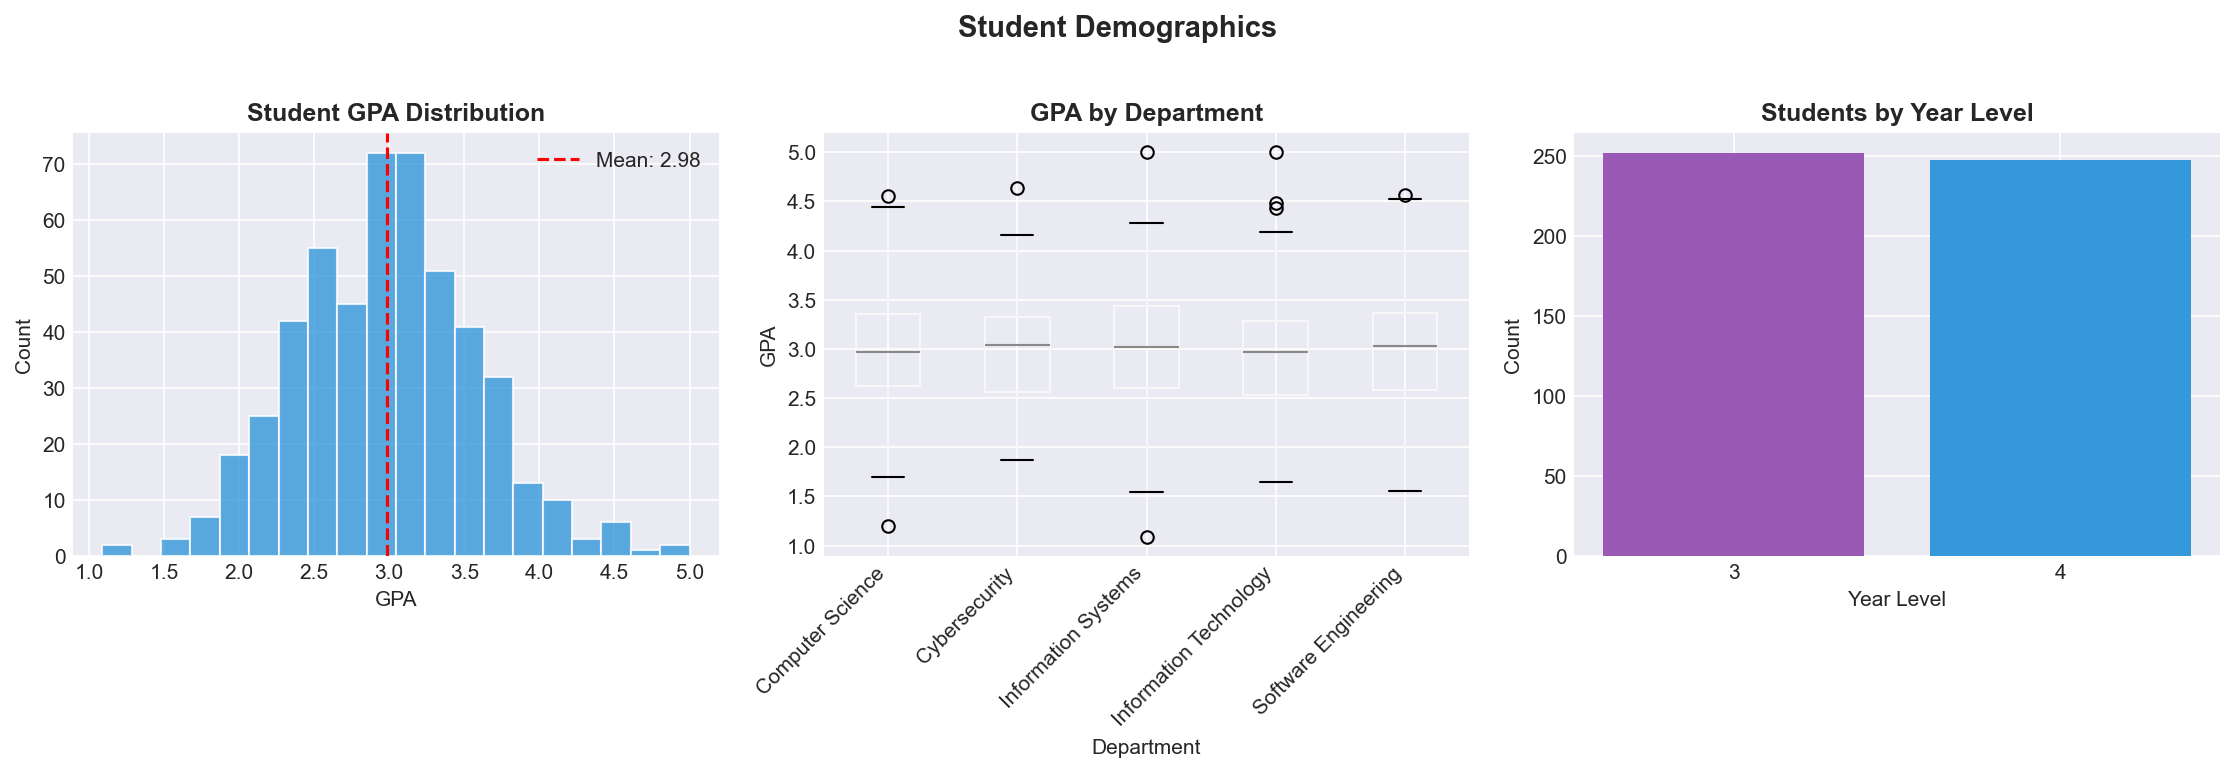

In [5]:
# Plot 3: Student Demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(students['gpa'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(students['gpa'].mean(), color='red', linestyle='--', label=f"Mean: {students['gpa'].mean():.2f}")
axes[0].set_title('Student GPA Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Count')
axes[0].legend()

students.boxplot(column='gpa', by='department', ax=axes[1], rot=45)
axes[1].set_title('GPA by Department', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('GPA')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

year_counts = students['year_level'].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(str), year_counts.values, color=['#9b59b6', '#3498db'])
axes[2].set_title('Students by Year Level', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Year Level')
axes[2].set_ylabel('Count')

plt.suptitle('Student Demographics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('03_student_demographics.png')

  Saved: C:\kb\student project\plots\04_wordclouds.png


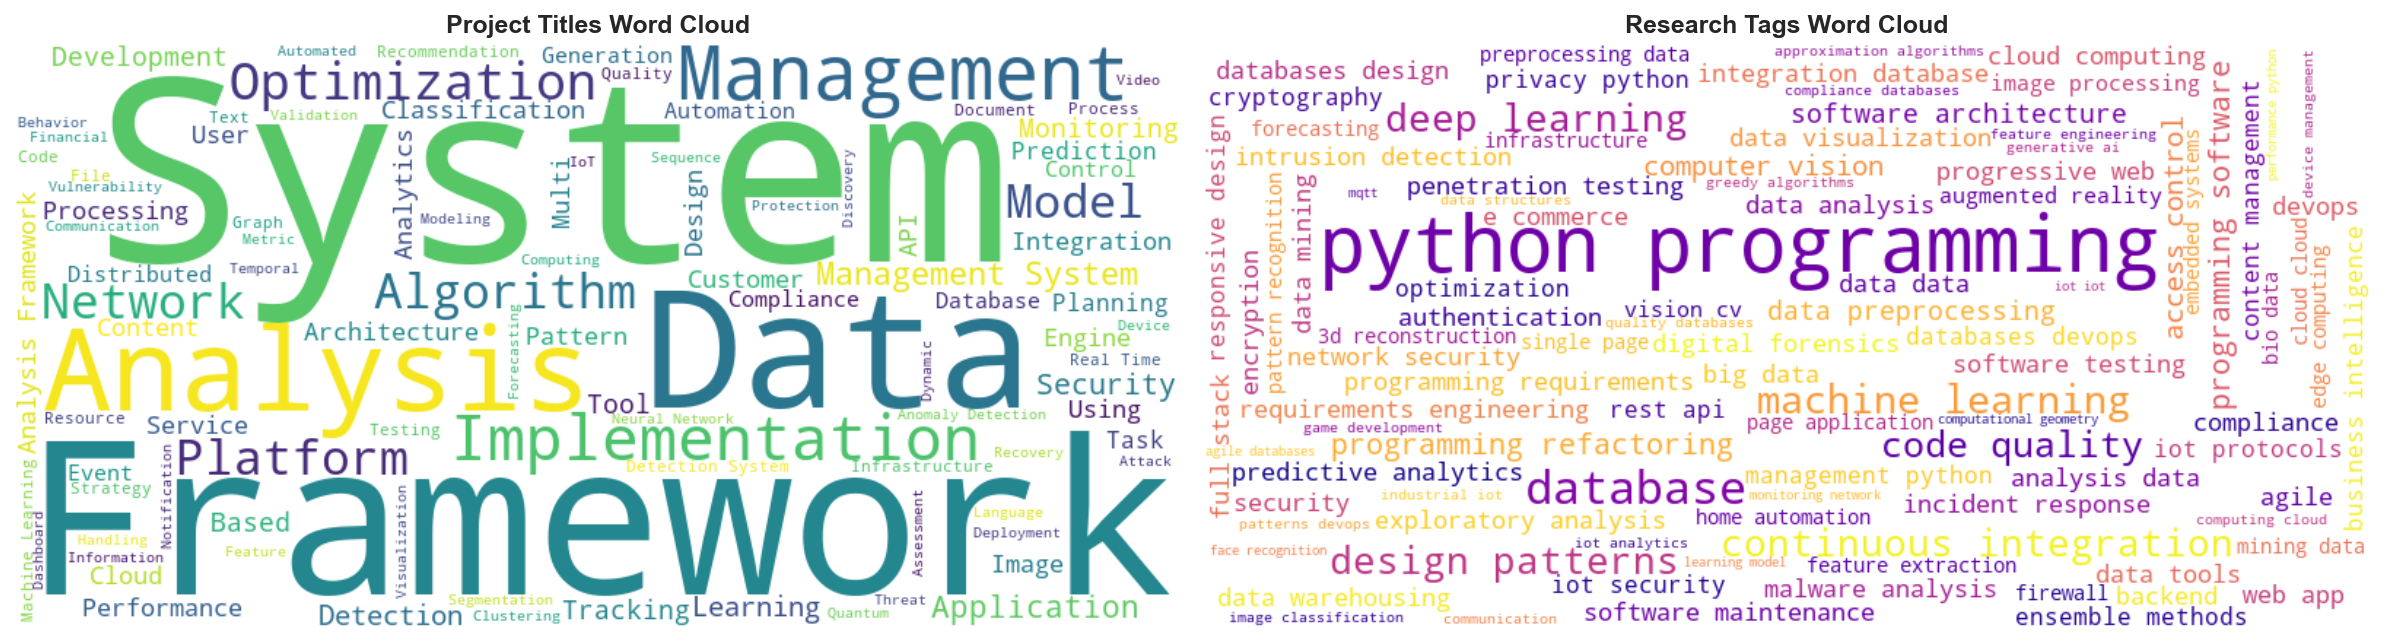

In [6]:
# Plot 4: Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_titles = ' '.join(projects['title'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(all_titles)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Project Titles Word Cloud', fontsize=12, fontweight='bold')

all_tags = ' '.join(projects['research_tags'].tolist())
wordcloud2 = WordCloud(width=800, height=400, background_color='white',
                       colormap='plasma', max_words=100).generate(all_tags)
axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Research Tags Word Cloud', fontsize=12, fontweight='bold')

plt.tight_layout()
save_plot('04_wordclouds.png')

  Saved: C:\kb\student project\plots\05_history_analysis.png


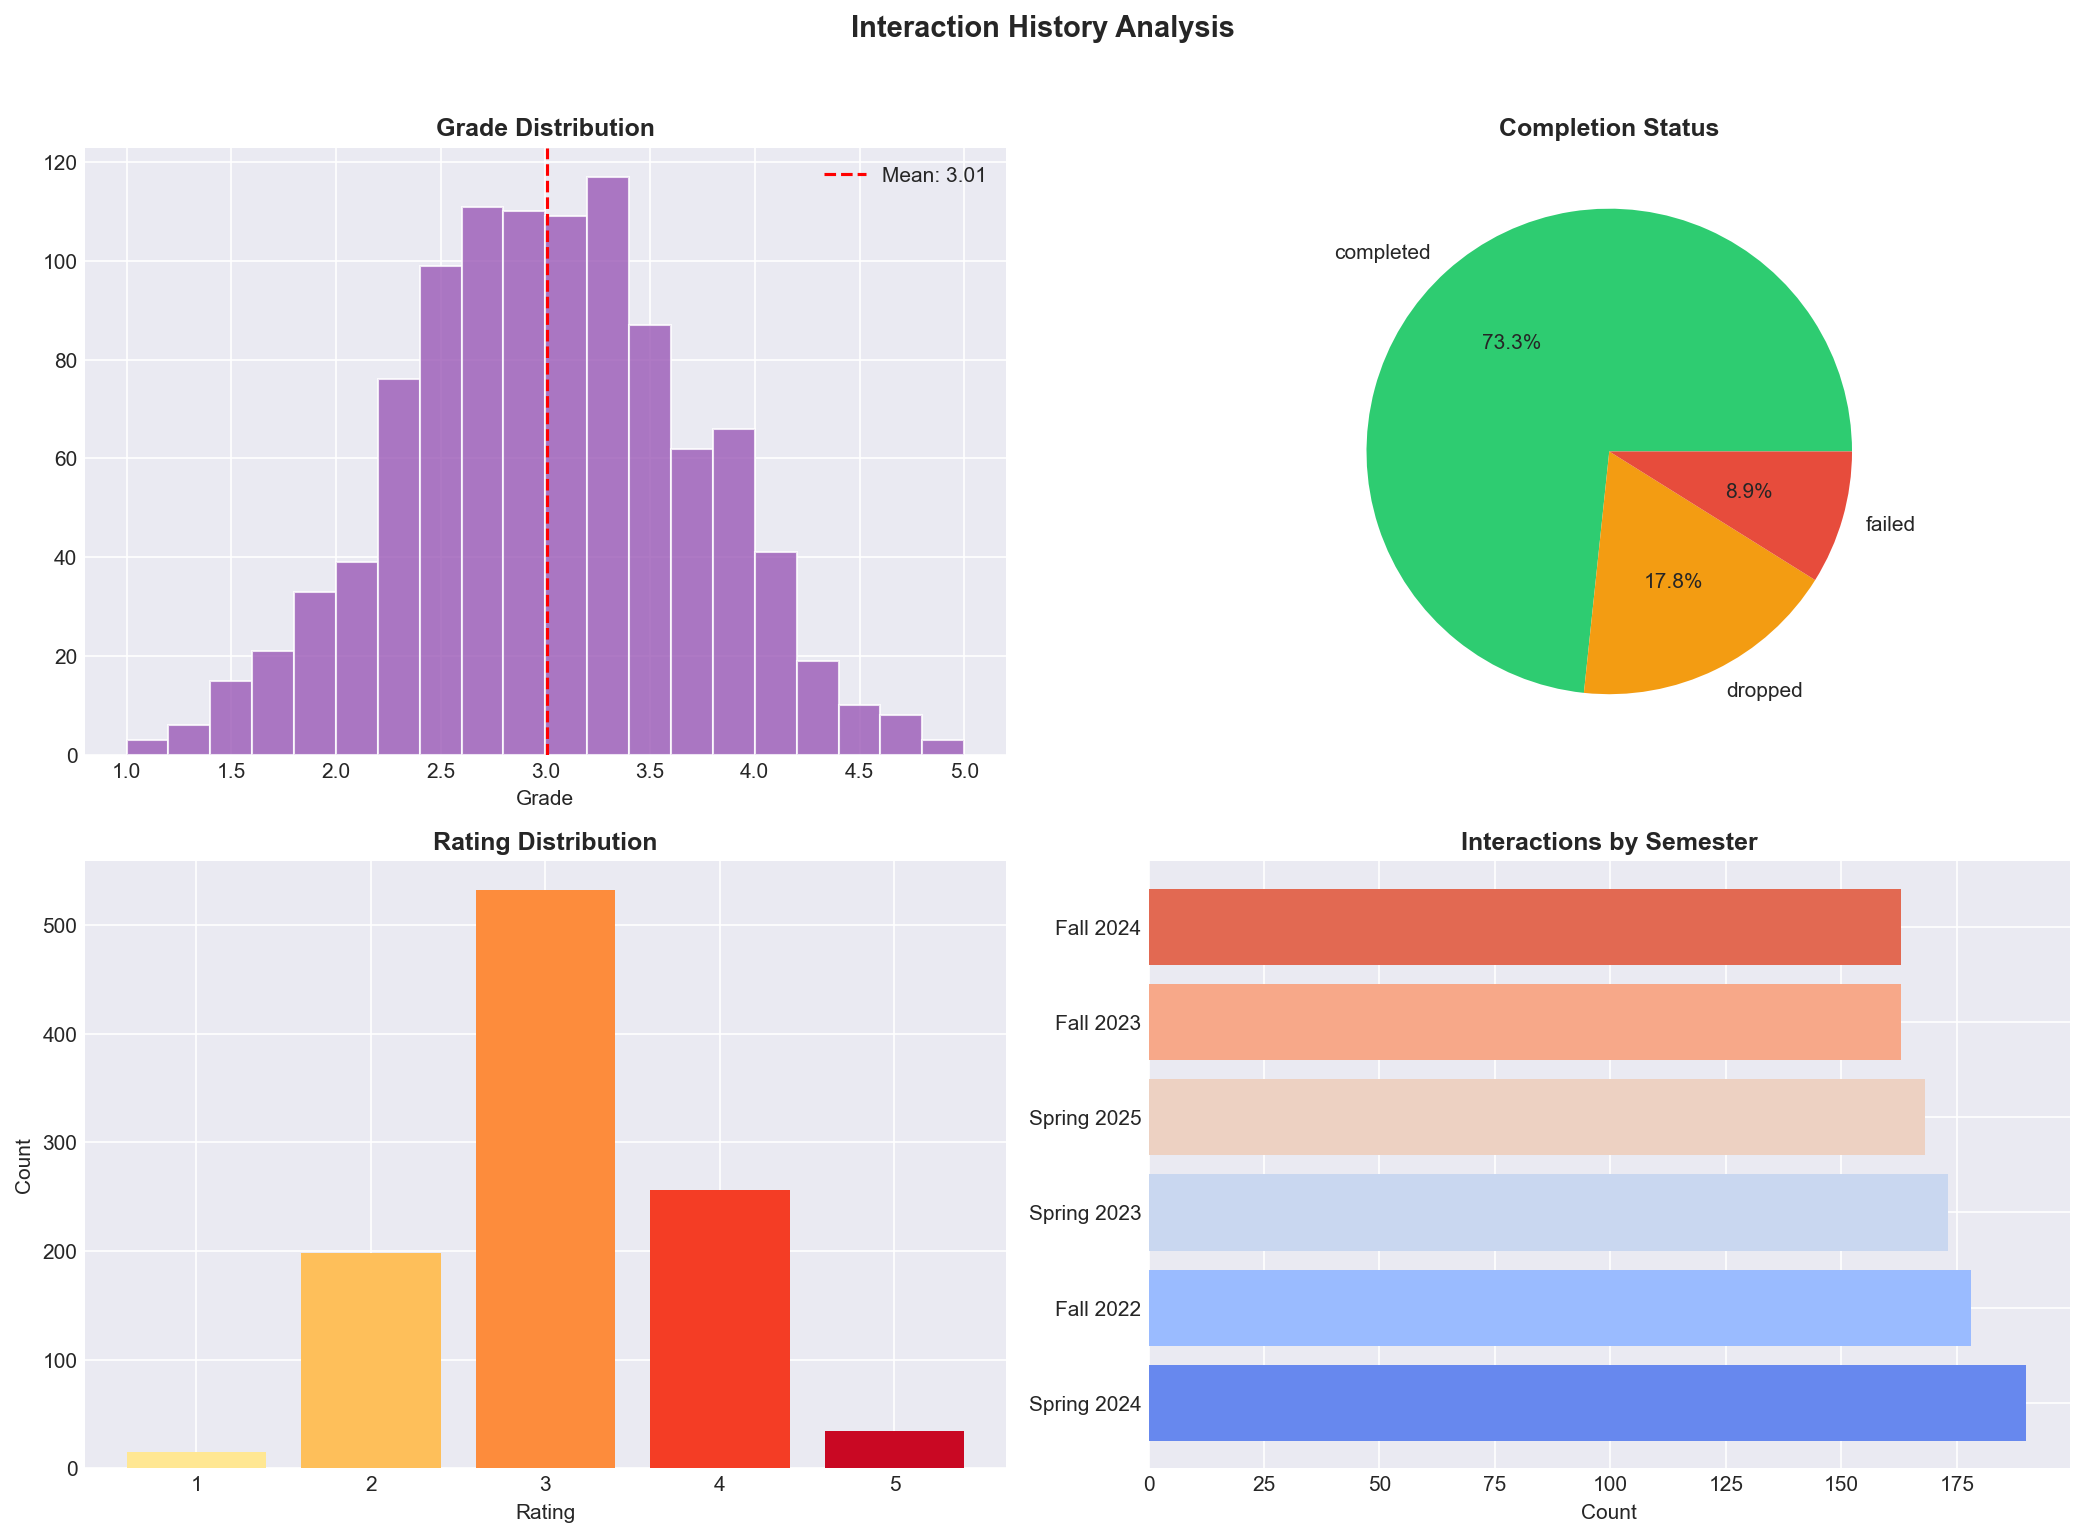

In [7]:
# Plot 5: History Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(history['grade'], bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(history['grade'].mean(), color='red', linestyle='--',
                    label=f"Mean: {history['grade'].mean():.2f}")
axes[0, 0].set_title('Grade Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Grade')
axes[0, 0].legend()

status_counts = history['completion_status'].value_counts()
colors_status = {'completed': '#2ecc71', 'dropped': '#f39c12', 'failed': '#e74c3c'}
axes[0, 1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
               colors=[colors_status.get(x, '#95a5a6') for x in status_counts.index])
axes[0, 1].set_title('Completion Status', fontsize=12, fontweight='bold')

rating_counts = history['rating'].value_counts().sort_index()
axes[1, 0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette("YlOrRd", 5))
axes[1, 0].set_title('Rating Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Count')

sem_counts = history['semester'].value_counts()
axes[1, 1].barh(sem_counts.index, sem_counts.values, color=sns.color_palette("coolwarm", len(sem_counts)))
axes[1, 1].set_title('Interactions by Semester', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.suptitle('Interaction History Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('05_history_analysis.png')

## 3. Feature Engineering

In [8]:
# Initialize encoders
dept_encoder = LabelEncoder()
cat_encoder = LabelEncoder()
research_area_encoder = LabelEncoder()
scaler = MinMaxScaler()

# Student features
students['dept_encoded'] = dept_encoder.fit_transform(students['department'])
diff_map = {'Easy': 0, 'Medium': 1, 'Hard': 2}
students['pref_diff_encoded'] = students['preferred_difficulty'].map(diff_map)
students['gpa_norm'] = scaler.fit_transform(students[['gpa']])
students['avg_cs_grade_norm'] = scaler.fit_transform(students[['avg_cs_grade']])
students['prog_langs_list'] = students['programming_languages'].str.split(', ')
students['fw_tools_list'] = students['frameworks_tools'].str.split(', ')
students['interests_list'] = students['interests'].str.split(', ')

# Project features
projects['dept_encoded'] = dept_encoder.transform(projects['department'])
projects['diff_encoded'] = projects['difficulty'].map(diff_map)
projects['cat_encoded'] = cat_encoder.fit_transform(projects['category'])
projects['research_area_encoded'] = research_area_encoder.fit_transform(projects['research_area'])
projects['avg_grade_norm'] = scaler.fit_transform(projects[['avg_grade_given']])
projects['times_selected_norm'] = scaler.fit_transform(projects[['times_selected']])
projects['skills_list'] = projects['required_skills'].str.split(', ')
projects['tech_list'] = projects['tech_stack'].str.split(', ')
projects['research_tags_list'] = projects['research_tags'].str.split(', ')

print(f"Student features: {students.shape[1]} columns")
print(f"Project features: {projects.shape[1]} columns")

Student features: 19 columns
Project features: 21 columns


In [9]:
# TF-IDF Vectorization
# For interests
interest_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
interest_tfidf = interest_vectorizer.fit_transform(students['interests'])

# For project text (title + description + research_tags)
projects['text_content'] = projects['title'] + ' ' + projects['description'] + ' ' + projects['research_tags']
project_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
project_tfidf = project_vectorizer.fit_transform(projects['text_content'])

# For research tags
research_tag_vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
research_tags_tfidf = research_tag_vectorizer.fit_transform(projects['research_tags'])

print(f"Interest TF-IDF: {interest_tfidf.shape}")
print(f"Project TF-IDF: {project_tfidf.shape}")
print(f"Research Tags TF-IDF: {research_tags_tfidf.shape}")

Interest TF-IDF: (500, 88)
Project TF-IDF: (1628, 200)
Research Tags TF-IDF: (1628, 50)


## 4. Similarity Features (Enhanced)

In [10]:
def calculate_skill_match(student_skills, project_skills):
    """Calculate Jaccard similarity between student and project skills"""
    student_set = set([s.lower().strip() for s in student_skills])
    project_set = set([s.lower().strip() for s in project_skills])
    if not student_set or not project_set:
        return 0.0
    intersection = student_set.intersection(project_set)
    union = student_set.union(project_set)
    return len(intersection) / len(union) if union else 0.0

def calculate_research_overlap(student_interests, project_research_tags):
    """Calculate overlap between student interests and project research tags"""
    interest_set = set([i.lower().strip() for i in student_interests])
    tag_set = set([t.lower().strip() for t in project_research_tags])
    if not interest_set or not tag_set:
        return 0.0
    intersection = interest_set.intersection(tag_set)
    union = interest_set.union(tag_set)
    return len(intersection) / len(union) if union else 0.0

def calculate_tech_stack_similarity(student_langs, student_tools, project_skills, project_tech):
    """Calculate tech stack compatibility"""
    student_tech = set([s.lower() for s in student_langs + student_tools])
    project_tech_set = set([s.lower() for s in project_skills + project_tech])
    if not student_tech or not project_tech_set:
        return 0.0
    intersection = student_tech.intersection(project_tech_set)
    union = student_tech.union(project_tech_set)
    return len(intersection) / len(union) if union else 0.0

def calculate_career_alignment(student_dept, student_gpa, student_pref_diff, 
                               student_skills, student_interests,
                               project_dept, project_diff, project_research_area):
    """Calculate career alignment score"""
    score = 0.0
    
    # Department match (0.3 weight)
    if student_dept == project_dept:
        score += 0.3
    
    # Difficulty match (0.2 weight)
    diff_map = {'Easy': 0, 'Medium': 1, 'Hard': 2}
    diff_diff = abs(diff_map.get(student_pref_diff, 1) - diff_map.get(project_diff, 1))
    score += 0.2 * (1 - diff_diff / 2)
    
    # GPA-difficulty fit (0.2 weight)
    if project_diff == 'Easy' and student_gpa >= 2.0:
        score += 0.2
    elif project_diff == 'Medium' and 2.5 <= student_gpa <= 4.0:
        score += 0.2
    elif project_diff == 'Hard' and student_gpa >= 3.0:
        score += 0.2
    else:
        score += 0.1
    
    # Research area alignment (0.3 weight)
    # This is simplified - in practice, you'd have a mapping
    score += 0.3 * 0.5  # Placeholder
    
    return min(1.0, score)

print("Similarity functions defined!")

Similarity functions defined!


## 5. Pre-compute Similarity Matrices

In [11]:
n_students = len(students)
n_projects = len(projects)

# Pre-compute student features
student_features_df = students[['dept_encoded', 'year_level', 'gpa_norm',
                                 'avg_cs_grade_norm', 'pref_diff_encoded', 'num_past_projects']].values

# Pre-compute project features
project_features_df = projects[['dept_encoded', 'diff_encoded', 'cat_encoded',
                                 'avg_grade_norm', 'times_selected_norm', 'research_area_encoded']].values

# Pre-compute department match matrix
dept_match_matrix = (students['department'].values[:, None] == projects['department'].values[None, :]).astype(float)

# Pre-compute difficulty match matrix
diff_match_matrix = 1.0 - np.abs(students['pref_diff_encoded'].values[:, None] -
                                  projects['diff_encoded'].values[None, :]) / 2.0

print(f"Student features: {student_features_df.shape}")
print(f"Project features: {project_features_df.shape}")

Student features: (500, 6)
Project features: (1628, 6)


In [12]:
# Pre-compute content scores using TF-IDF similarity
print("Pre-computing content scores...")
content_scores_all = np.zeros((n_students, n_projects))
for i in range(n_students):
    student = students.iloc[i]
    student_skills = student['prog_langs_list'] + student['fw_tools_list']
    student_text = student['interests'] + ' ' + ' '.join(student_skills)
    student_vec = project_vectorizer.transform([student_text])
    content_scores_all[i] = cosine_similarity(student_vec, project_tfidf).flatten()

print(f"Content scores: {content_scores_all.shape}")

Pre-computing content scores...
Content scores: (500, 1628)


In [13]:
# Pre-compute research overlap scores (NEW)
print("Pre-computing research overlap scores...")
research_overlap_all = np.zeros((n_students, n_projects))
for i in range(n_students):
    student_interests = students.iloc[i]['interests_list']
    for j in range(n_projects):
        project_tags = projects.iloc[j]['research_tags_list']
        research_overlap_all[i, j] = calculate_research_overlap(student_interests, project_tags)

print(f"Research overlap: {research_overlap_all.shape}")

Pre-computing research overlap scores...
Research overlap: (500, 1628)


In [14]:
# Pre-compute tech stack similarity (NEW)
print("Pre-computing tech stack similarity...")
tech_similarity_all = np.zeros((n_students, n_projects))
for i in range(n_students):
    student_langs = students.iloc[i]['prog_langs_list']
    student_tools = students.iloc[i]['fw_tools_list']
    for j in range(n_projects):
        project_skills = projects.iloc[j]['skills_list']
        project_tech = projects.iloc[j]['tech_list']
        tech_similarity_all[i, j] = calculate_tech_stack_similarity(
            student_langs, student_tools, project_skills, project_tech)

print(f"Tech similarity: {tech_similarity_all.shape}")

Pre-computing tech stack similarity...
Tech similarity: (500, 1628)


In [15]:
# Pre-compute career alignment scores (NEW)
print("Pre-computing career alignment scores...")
career_alignment_all = np.zeros((n_students, n_projects))
for i in range(n_students):
    student = students.iloc[i]
    for j in range(n_projects):
        project = projects.iloc[j]
        career_alignment_all[i, j] = calculate_career_alignment(
            student['department'], student['gpa'], student['preferred_difficulty'],
            student['prog_langs_list'] + student['fw_tools_list'],
            student['interests_list'],
            project['department'], project['difficulty'], project['research_area'])

print(f"Career alignment: {career_alignment_all.shape}")

Pre-computing career alignment scores...
Career alignment: (500, 1628)


In [16]:
# Pre-compute skill match matrix (optimized)
print("Pre-computing skill match matrix...")
student_skill_sets = [frozenset([s.lower() for s in students.iloc[i]['prog_langs_list'] + students.iloc[i]['fw_tools_list']])
                      for i in range(n_students)]
project_skill_sets = [frozenset([s.lower() for s in projects.iloc[j]['skills_list']])
                      for j in range(n_projects)]

skill_match_matrix = np.zeros((n_students, n_projects))
for i in range(n_students):
    s_set = student_skill_sets[i]
    if not s_set:
        continue
    for j in range(n_projects):
        p_set = project_skill_sets[j]
        if not p_set:
            continue
        intersection = len(s_set & p_set)
        if intersection > 0:
            union = len(s_set | p_set)
            skill_match_matrix[i, j] = intersection / union

print(f"Skill match: {skill_match_matrix.shape}")

Pre-computing skill match matrix...
Skill match: (500, 1628)


In [17]:
# Collaborative filtering scores
print("Building collaborative filtering...")

student_id_to_idx = {sid: i for i, sid in enumerate(students['student_id'])}
project_id_to_idx = {pid: i for i, pid in enumerate(projects['project_id'])}

rows, cols, vals = [], [], []
for _, row in history.iterrows():
    if row['student_id'] in student_id_to_idx and row['project_id'] in project_id_to_idx:
        rows.append(student_id_to_idx[row['student_id']])
        cols.append(project_id_to_idx[row['project_id']])
        vals.append(row['rating'])

interaction_matrix = csr_matrix((vals, (rows, cols)), shape=(n_students, n_projects))

# Apply SVD
n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
student_factors = svd.fit_transform(interaction_matrix)
project_factors = svd.components_.T

# Collaborative scores for all students
collab_scores_all = student_factors @ project_factors.T
for i in range(n_students):
    row = collab_scores_all[i]
    collab_scores_all[i] = (row - row.min()) / (row.max() - row.min() + 1e-8)

print(f"Collaborative scores: {collab_scores_all.shape}")

Building collaborative filtering...
Collaborative scores: (500, 1628)


  Saved: C:\kb\student project\plots\06_similarity_distributions.png


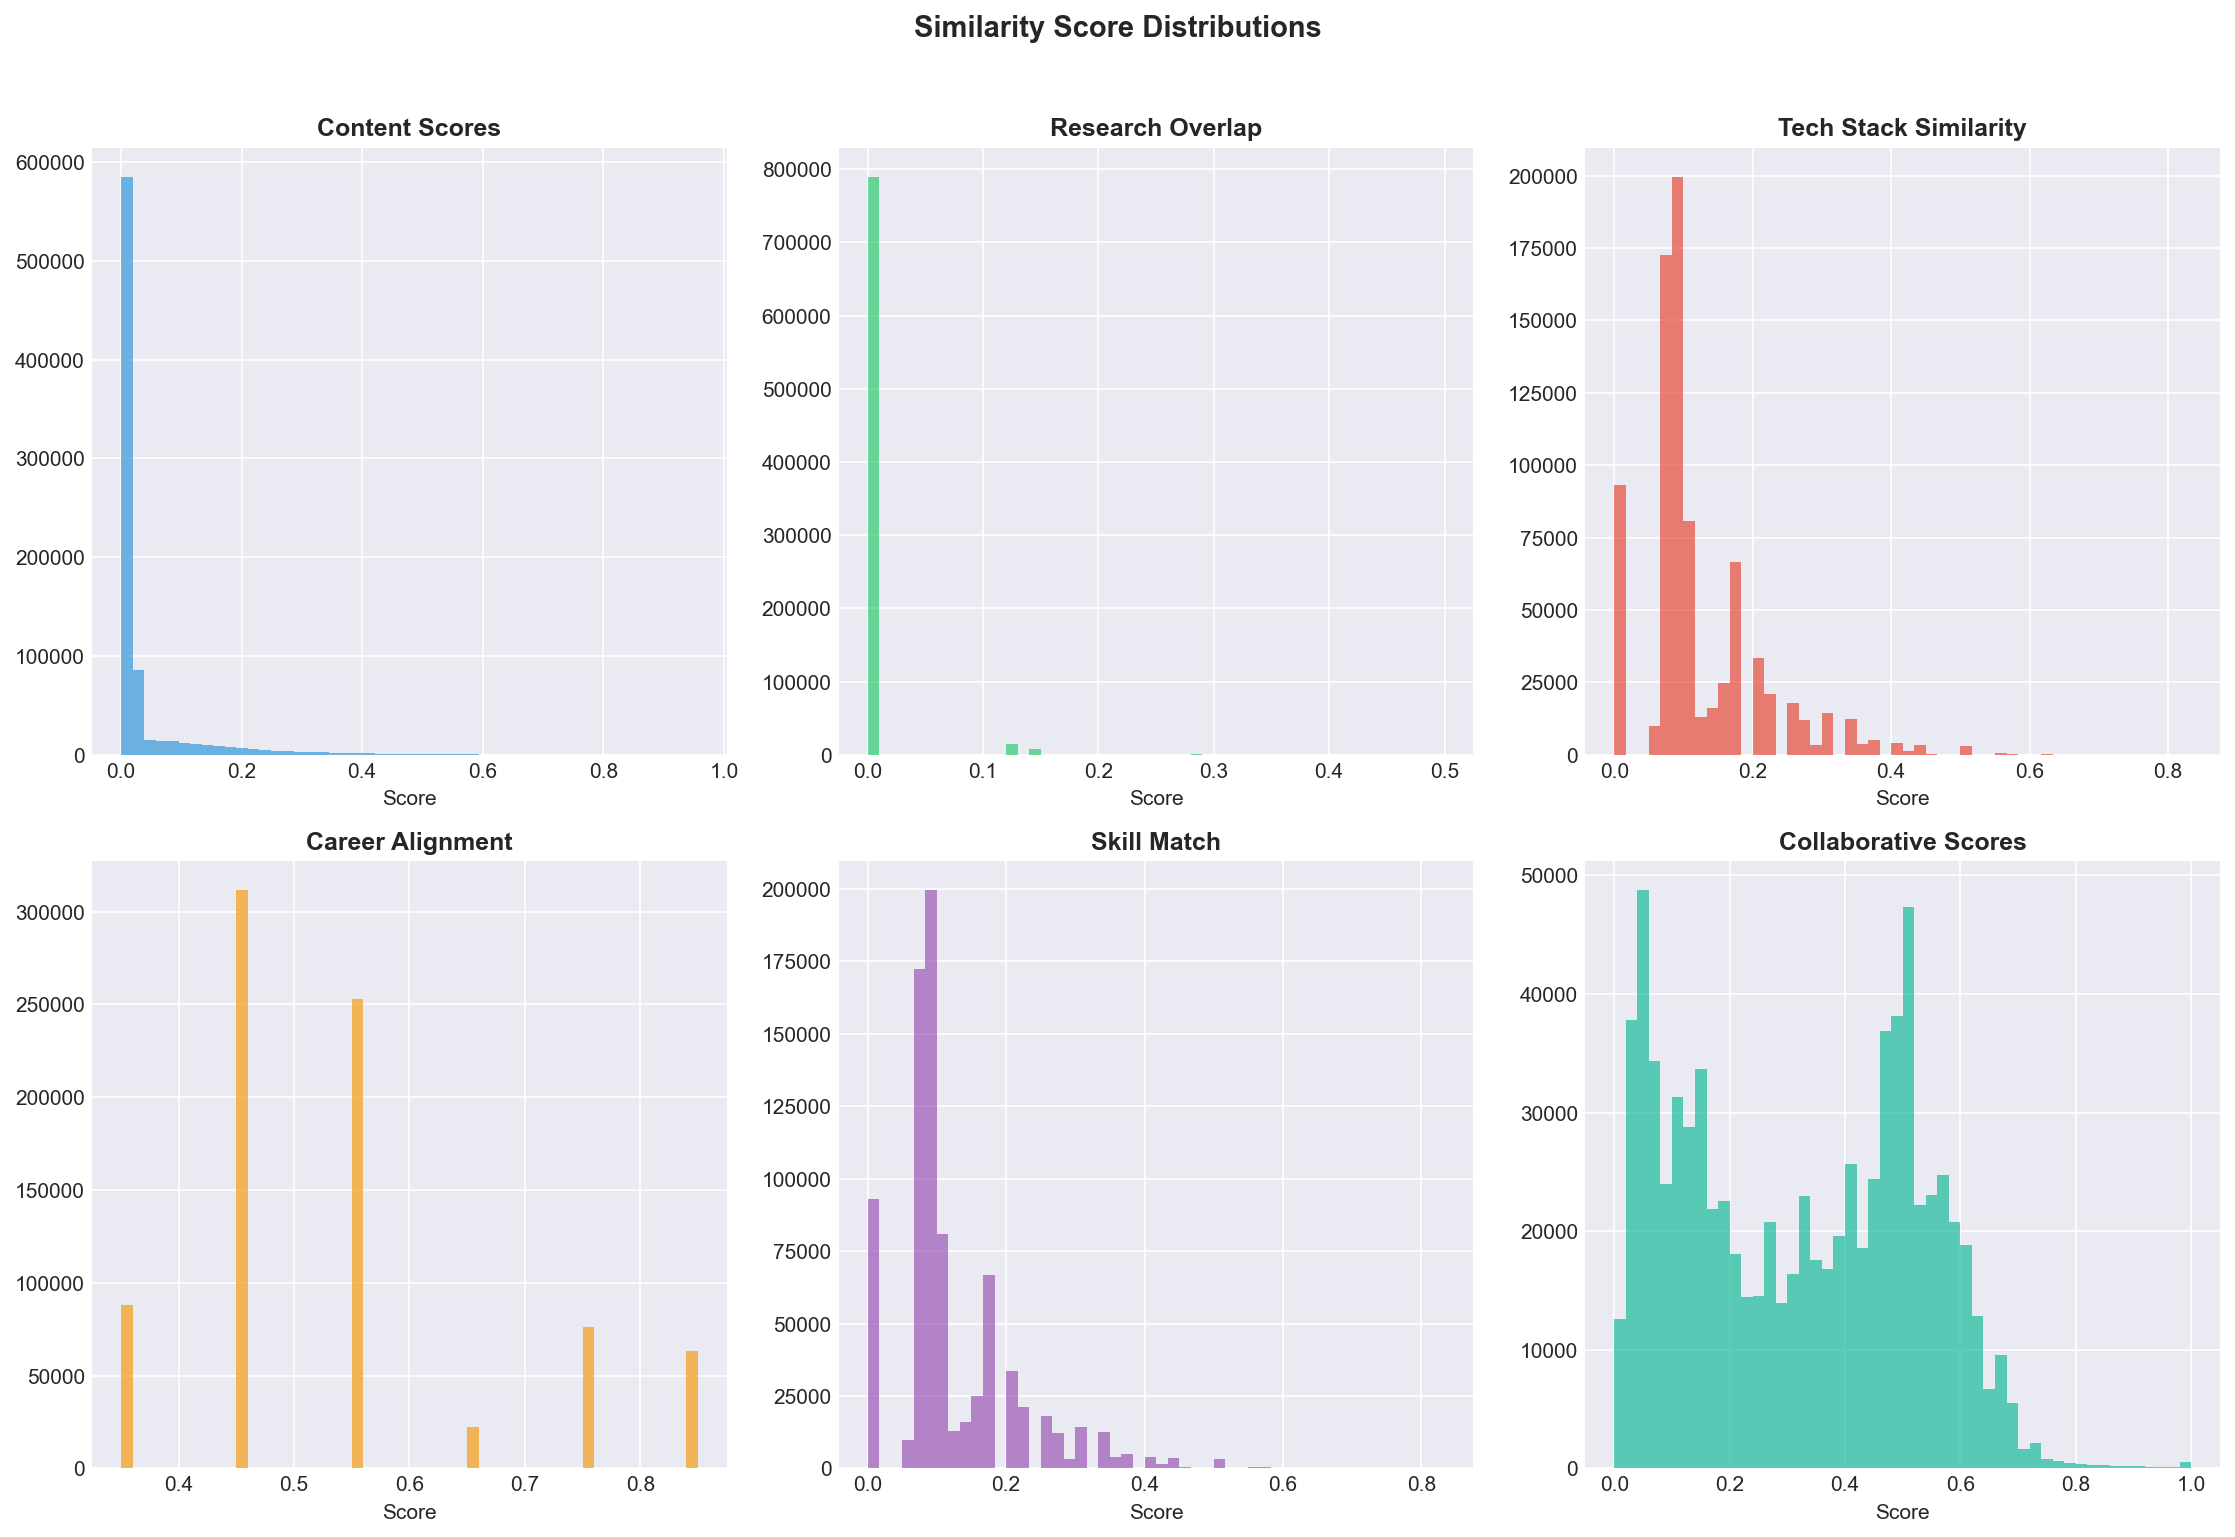

In [18]:
# Plot 6: Similarity Score Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Content scores
axes[0, 0].hist(content_scores_all.flatten(), bins=50, color='#3498db', alpha=0.7)
axes[0, 0].set_title('Content Scores', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Score')

# Research overlap
axes[0, 1].hist(research_overlap_all.flatten(), bins=50, color='#2ecc71', alpha=0.7)
axes[0, 1].set_title('Research Overlap', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Score')

# Tech similarity
axes[0, 2].hist(tech_similarity_all.flatten(), bins=50, color='#e74c3c', alpha=0.7)
axes[0, 2].set_title('Tech Stack Similarity', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Score')

# Career alignment
axes[1, 0].hist(career_alignment_all.flatten(), bins=50, color='#f39c12', alpha=0.7)
axes[1, 0].set_title('Career Alignment', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Score')

# Skill match
axes[1, 1].hist(skill_match_matrix.flatten(), bins=50, color='#9b59b6', alpha=0.7)
axes[1, 1].set_title('Skill Match', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Score')

# Collaborative scores
axes[1, 2].hist(collab_scores_all.flatten(), bins=50, color='#1abc9c', alpha=0.7)
axes[1, 2].set_title('Collaborative Scores', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Score')

plt.suptitle('Similarity Score Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('06_similarity_distributions.png')

## 6. Training Data Generation

In [19]:
# Generate positive and negative pairs
positive_pairs = []
for _, row in history.iterrows():
    if row['student_id'] in student_id_to_idx and row['project_id'] in project_id_to_idx:
        s_idx = student_id_to_idx[row['student_id']]
        p_idx = project_id_to_idx[row['project_id']]
        grade = row['grade']
        status = 1 if row['completion_status'] == 'completed' else 0
        # Convert to integer relevance (0-4) for XGBoost ranking
        raw_score = grade * 0.7 + status * 5 * 0.3
        relevance = min(4, max(0, int(round(raw_score))))
        positive_pairs.append((s_idx, p_idx, relevance))

negative_pairs = []
np.random.seed(42)
for s_idx, p_idx, _ in positive_pairs:
    for _ in range(3):
        neg_p_idx = np.random.randint(0, n_projects)
        negative_pairs.append((s_idx, neg_p_idx, 0))

all_pairs = positive_pairs + negative_pairs
print(f"Positive: {len(positive_pairs)}, Negative: {len(negative_pairs)}, Total: {len(all_pairs)}")

Positive: 1035, Negative: 3105, Total: 4140


## 7. Feature Matrix Construction

In [20]:
# Enhanced feature names
feature_names = [
    # Student features
    's_dept', 's_year', 's_gpa', 's_cs_grade', 's_pref_diff', 's_num_past',
    # Project features
    'p_dept', 'p_diff', 'p_cat', 'p_avg_grade', 'p_times_sel', 'p_research_area',
    # Similarity features
    'skill_match', 'dept_match', 'diff_match',
    'content_score', 'collab_score',
    # NEW similarity features
    'research_overlap', 'tech_similarity', 'career_alignment'
]

print(f"Total features: {len(feature_names)}")
print("Features:", feature_names)

Total features: 20
Features: ['s_dept', 's_year', 's_gpa', 's_cs_grade', 's_pref_diff', 's_num_past', 'p_dept', 'p_diff', 'p_cat', 'p_avg_grade', 'p_times_sel', 'p_research_area', 'skill_match', 'dept_match', 'diff_match', 'content_score', 'collab_score', 'research_overlap', 'tech_similarity', 'career_alignment']


In [21]:
# Build feature matrix
print("Building feature matrix...")
X_list = []
y_list = []

for s_idx, p_idx, relevance in all_pairs:
    features = [
        # Student features
        student_features_df[s_idx, 0],  # s_dept
        student_features_df[s_idx, 1],  # s_year
        student_features_df[s_idx, 2],  # s_gpa
        student_features_df[s_idx, 3],  # s_cs_grade
        student_features_df[s_idx, 4],  # s_pref_diff
        student_features_df[s_idx, 5],  # s_num_past
        # Project features
        project_features_df[p_idx, 0],  # p_dept
        project_features_df[p_idx, 1],  # p_diff
        project_features_df[p_idx, 2],  # p_cat
        project_features_df[p_idx, 3],  # p_avg_grade
        project_features_df[p_idx, 4],  # p_times_sel
        project_features_df[p_idx, 5],  # p_research_area
        # Similarity features
        skill_match_matrix[s_idx, p_idx],
        dept_match_matrix[s_idx, p_idx],
        diff_match_matrix[s_idx, p_idx],
        content_scores_all[s_idx, p_idx],
        collab_scores_all[s_idx, p_idx],
        # NEW similarity features
        research_overlap_all[s_idx, p_idx],
        tech_similarity_all[s_idx, p_idx],
        career_alignment_all[s_idx, p_idx]
    ]
    X_list.append(features)
    y_list.append(relevance)

X = np.array(X_list)
y = np.array(y_list)
print(f"Feature matrix: {X.shape}")

Building feature matrix...
Feature matrix: (4140, 20)


  Saved: C:\kb\student project\plots\07_feature_distributions.png


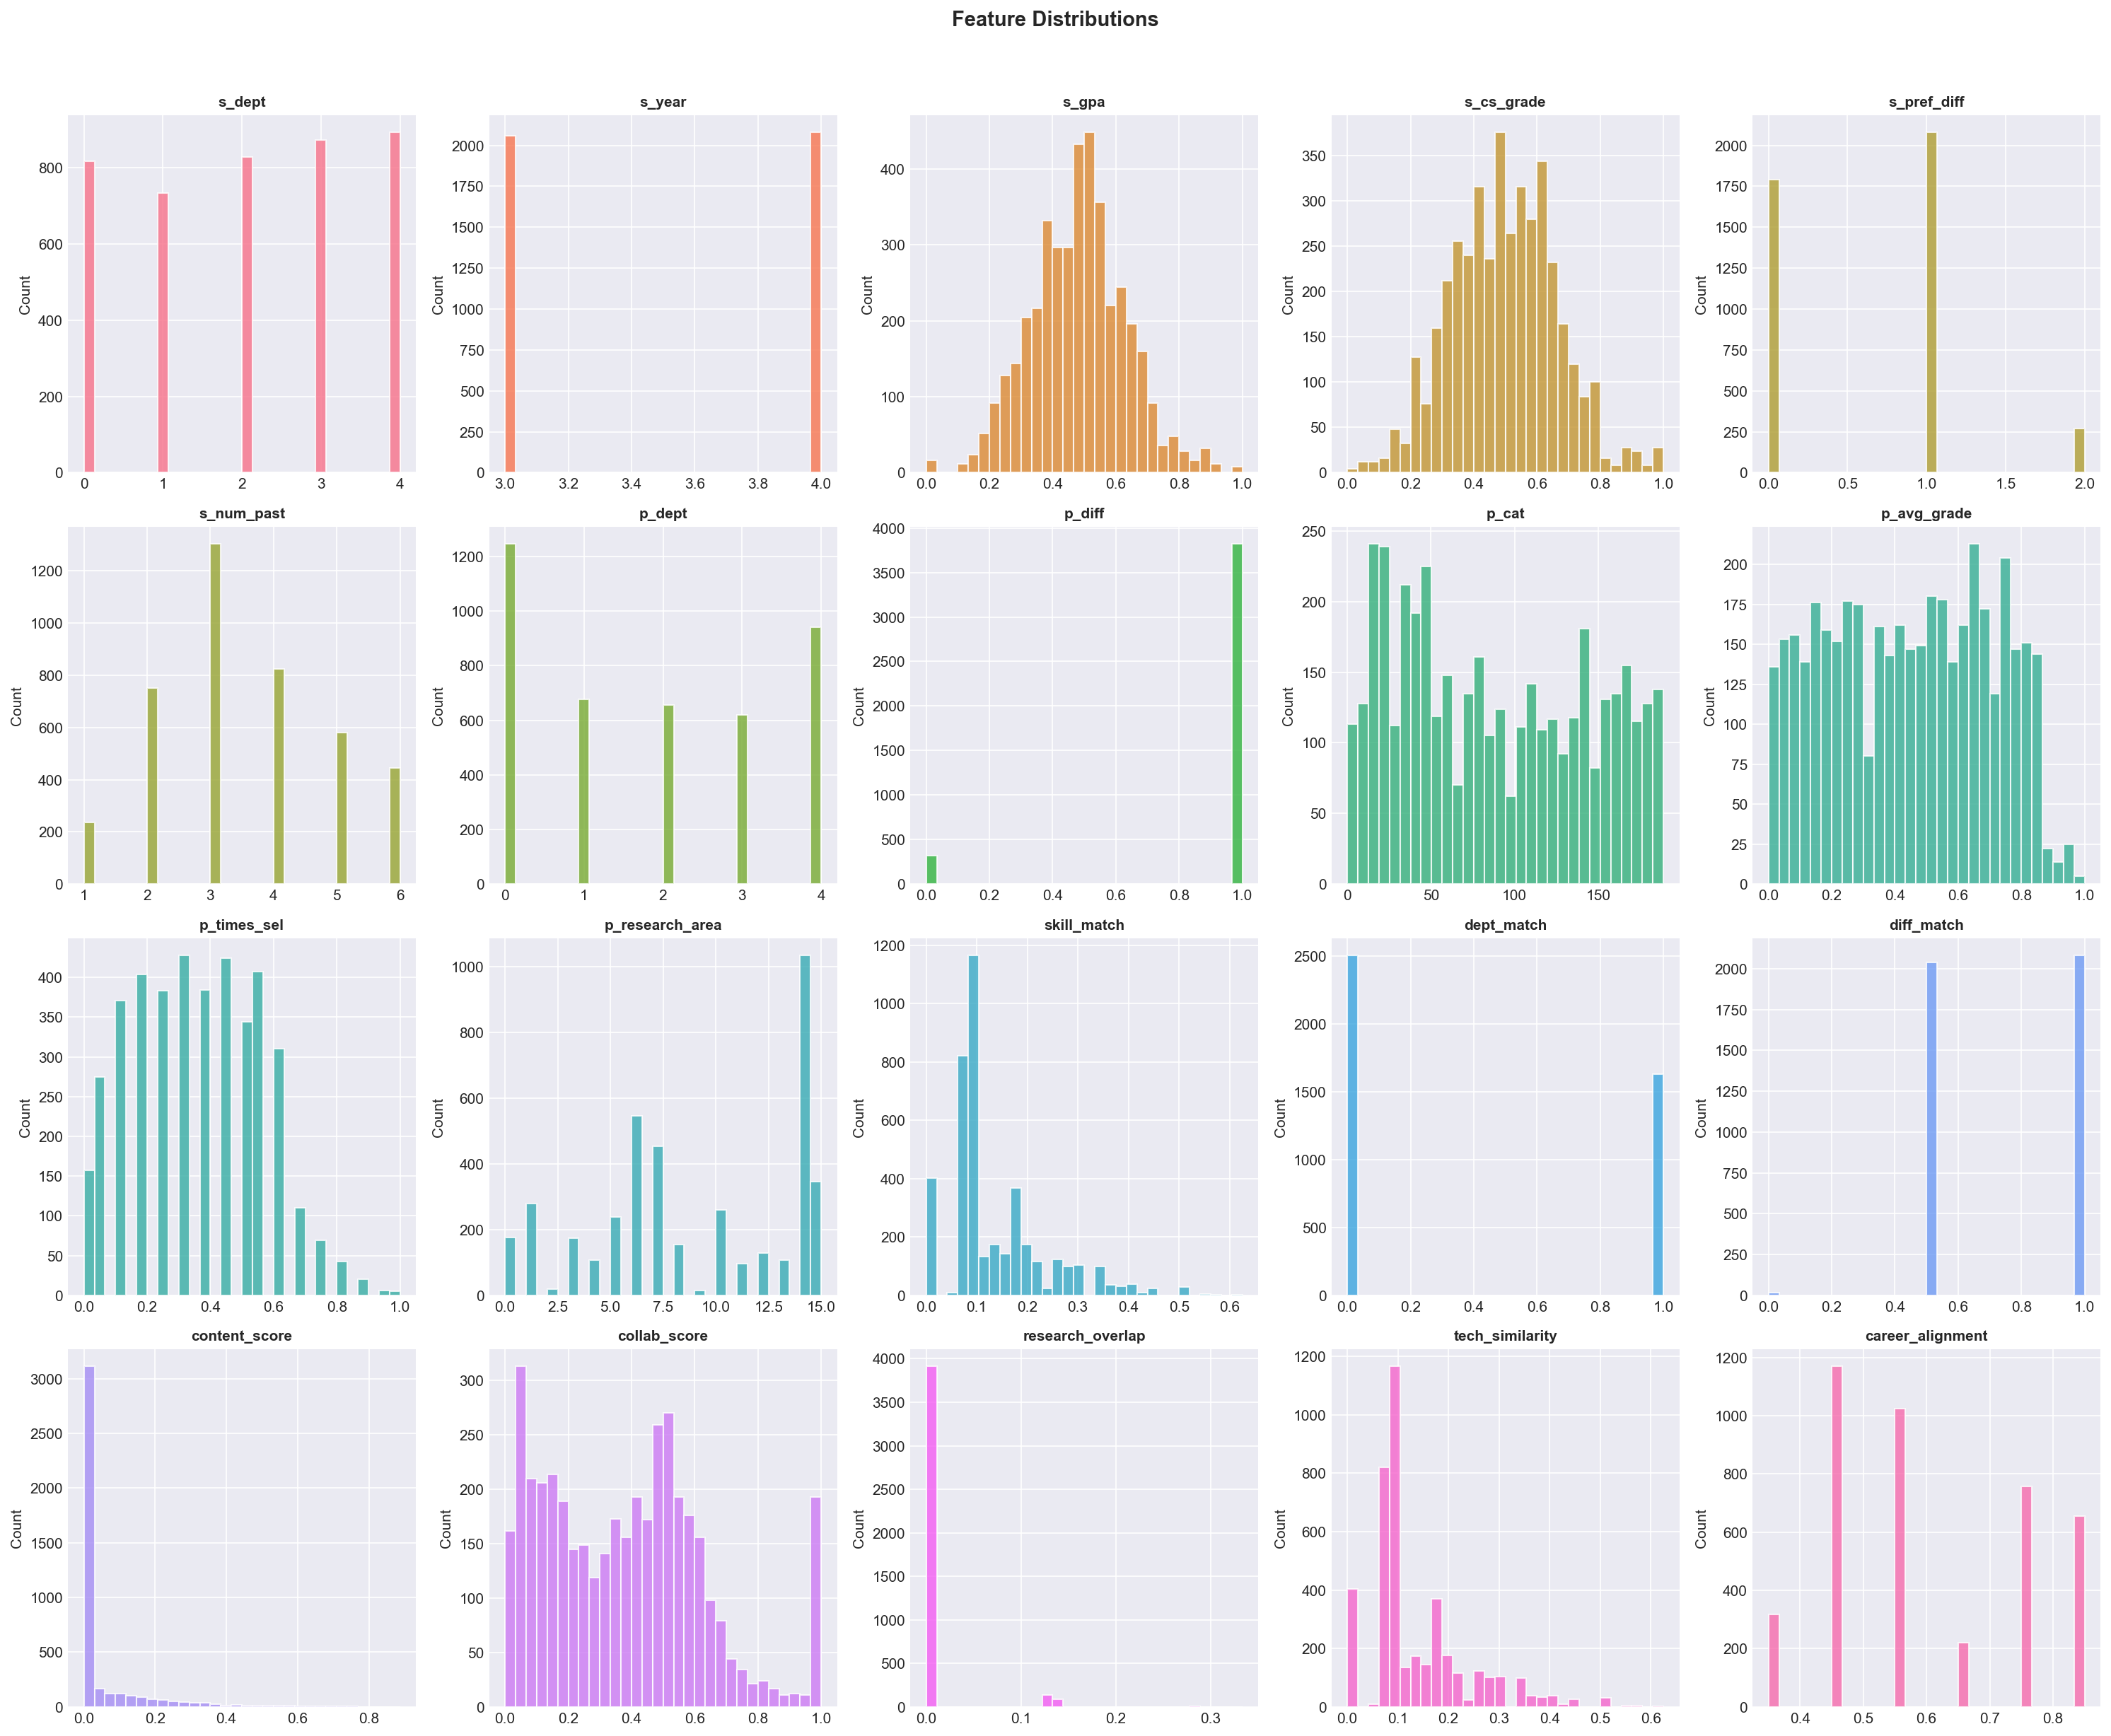

In [22]:
# Plot 7: Feature Distributions
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, feat_name in enumerate(feature_names):
    if i < len(axes):
        axes[i].hist(X[:, i], bins=30, color=sns.color_palette("husl", len(feature_names))[i], edgecolor='white', alpha=0.8)
        axes[i].set_title(f'{feat_name}', fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Count')

# Hide unused axes
for i in range(len(feature_names), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('07_feature_distributions.png')

  Saved: C:\kb\student project\plots\08_feature_correlations_target.png


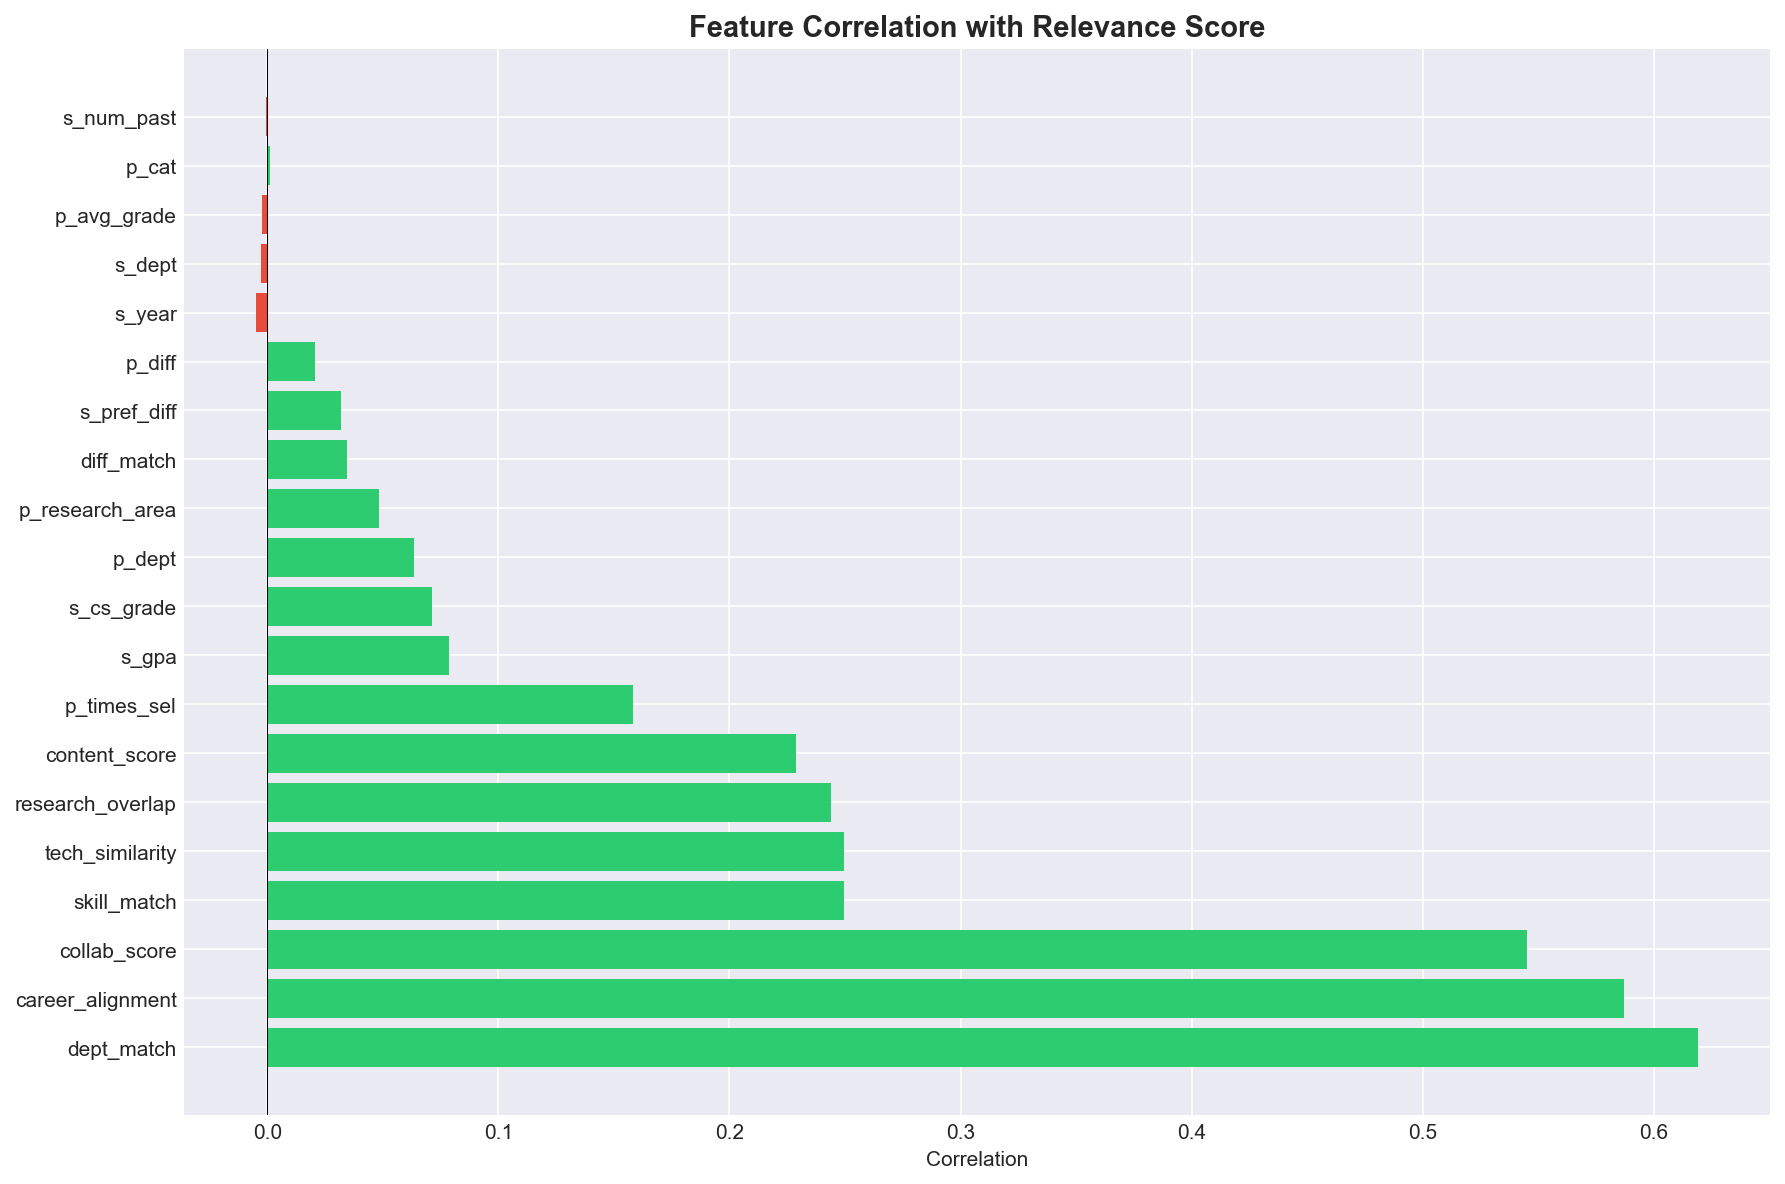

In [23]:
# Plot 8: Feature Correlations with Target
fig, ax = plt.subplots(figsize=(12, 8))

feature_corrs = []
for i, feat_name in enumerate(feature_names):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    feature_corrs.append((feat_name, corr))

feature_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
feat_names_sorted = [f[0] for f in feature_corrs]
corr_values = [f[1] for f in feature_corrs]

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in corr_values]
ax.barh(feat_names_sorted, corr_values, color=colors)
ax.set_title('Feature Correlation with Relevance Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
save_plot('08_feature_correlations_target.png')

## 8. XGBoost Ranker Training

In [24]:
# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)

params = {
    'objective': 'rank:pairwise',
    'eval_metric': 'ndcg',
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'seed': 42
}

evals_result = {}
model = xgb.train(params, dtrain, num_boost_round=200,
                  evals=[(dtrain, 'train'), (dtest, 'test')],
                  evals_result=evals_result, early_stopping_rounds=20, verbose_eval=50)

[0]	train-ndcg:0.42181	test-ndcg:0.53303
[28]	train-ndcg:0.97842	test-ndcg:0.98311


  Saved: C:\kb\student project\plots\09_xgboost_training.png


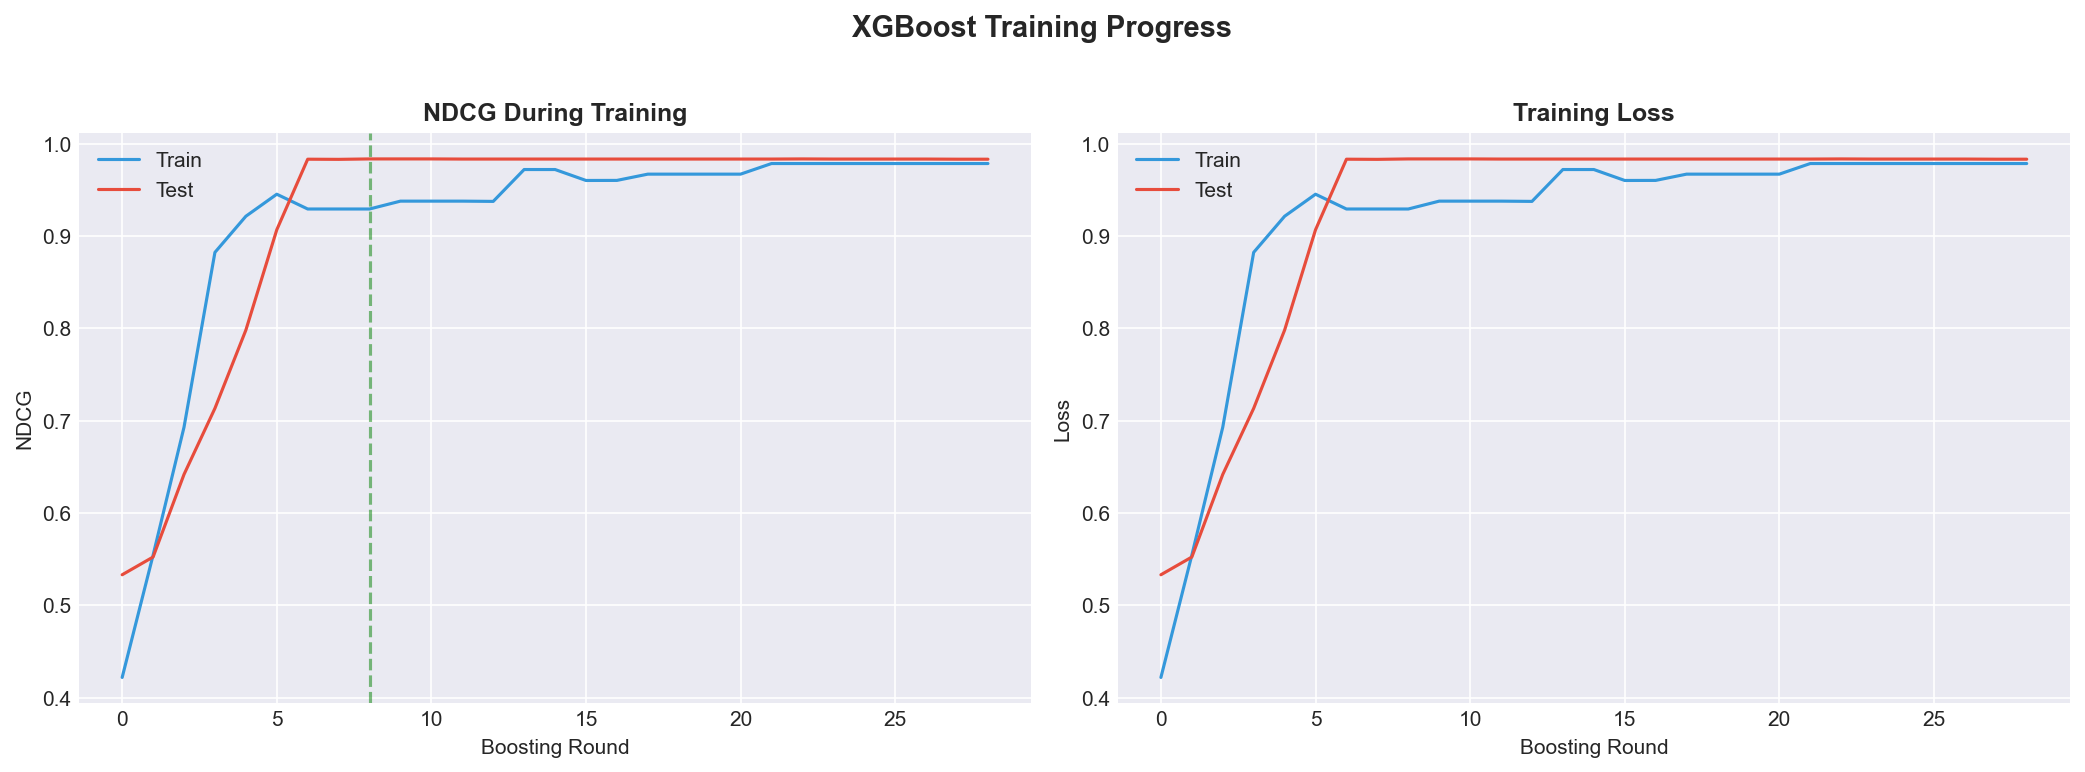

In [25]:
# Plot 9: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evals_result['train']['ndcg'], label='Train', color='#3498db')
axes[0].plot(evals_result['test']['ndcg'], label='Test', color='#e74c3c')
axes[0].set_title('NDCG During Training', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('NDCG')
axes[0].legend()
axes[0].axvline(x=model.best_iteration, color='green', linestyle='--', alpha=0.5)

axes[1].plot(evals_result['train'].get('ndcg', []), label='Train', color='#3498db')
axes[1].plot(evals_result['test'].get('ndcg', []), label='Test', color='#e74c3c')
axes[1].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('XGBoost Training Progress', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('09_xgboost_training.png')

  Saved: C:\kb\student project\plots\10_feature_importance.png


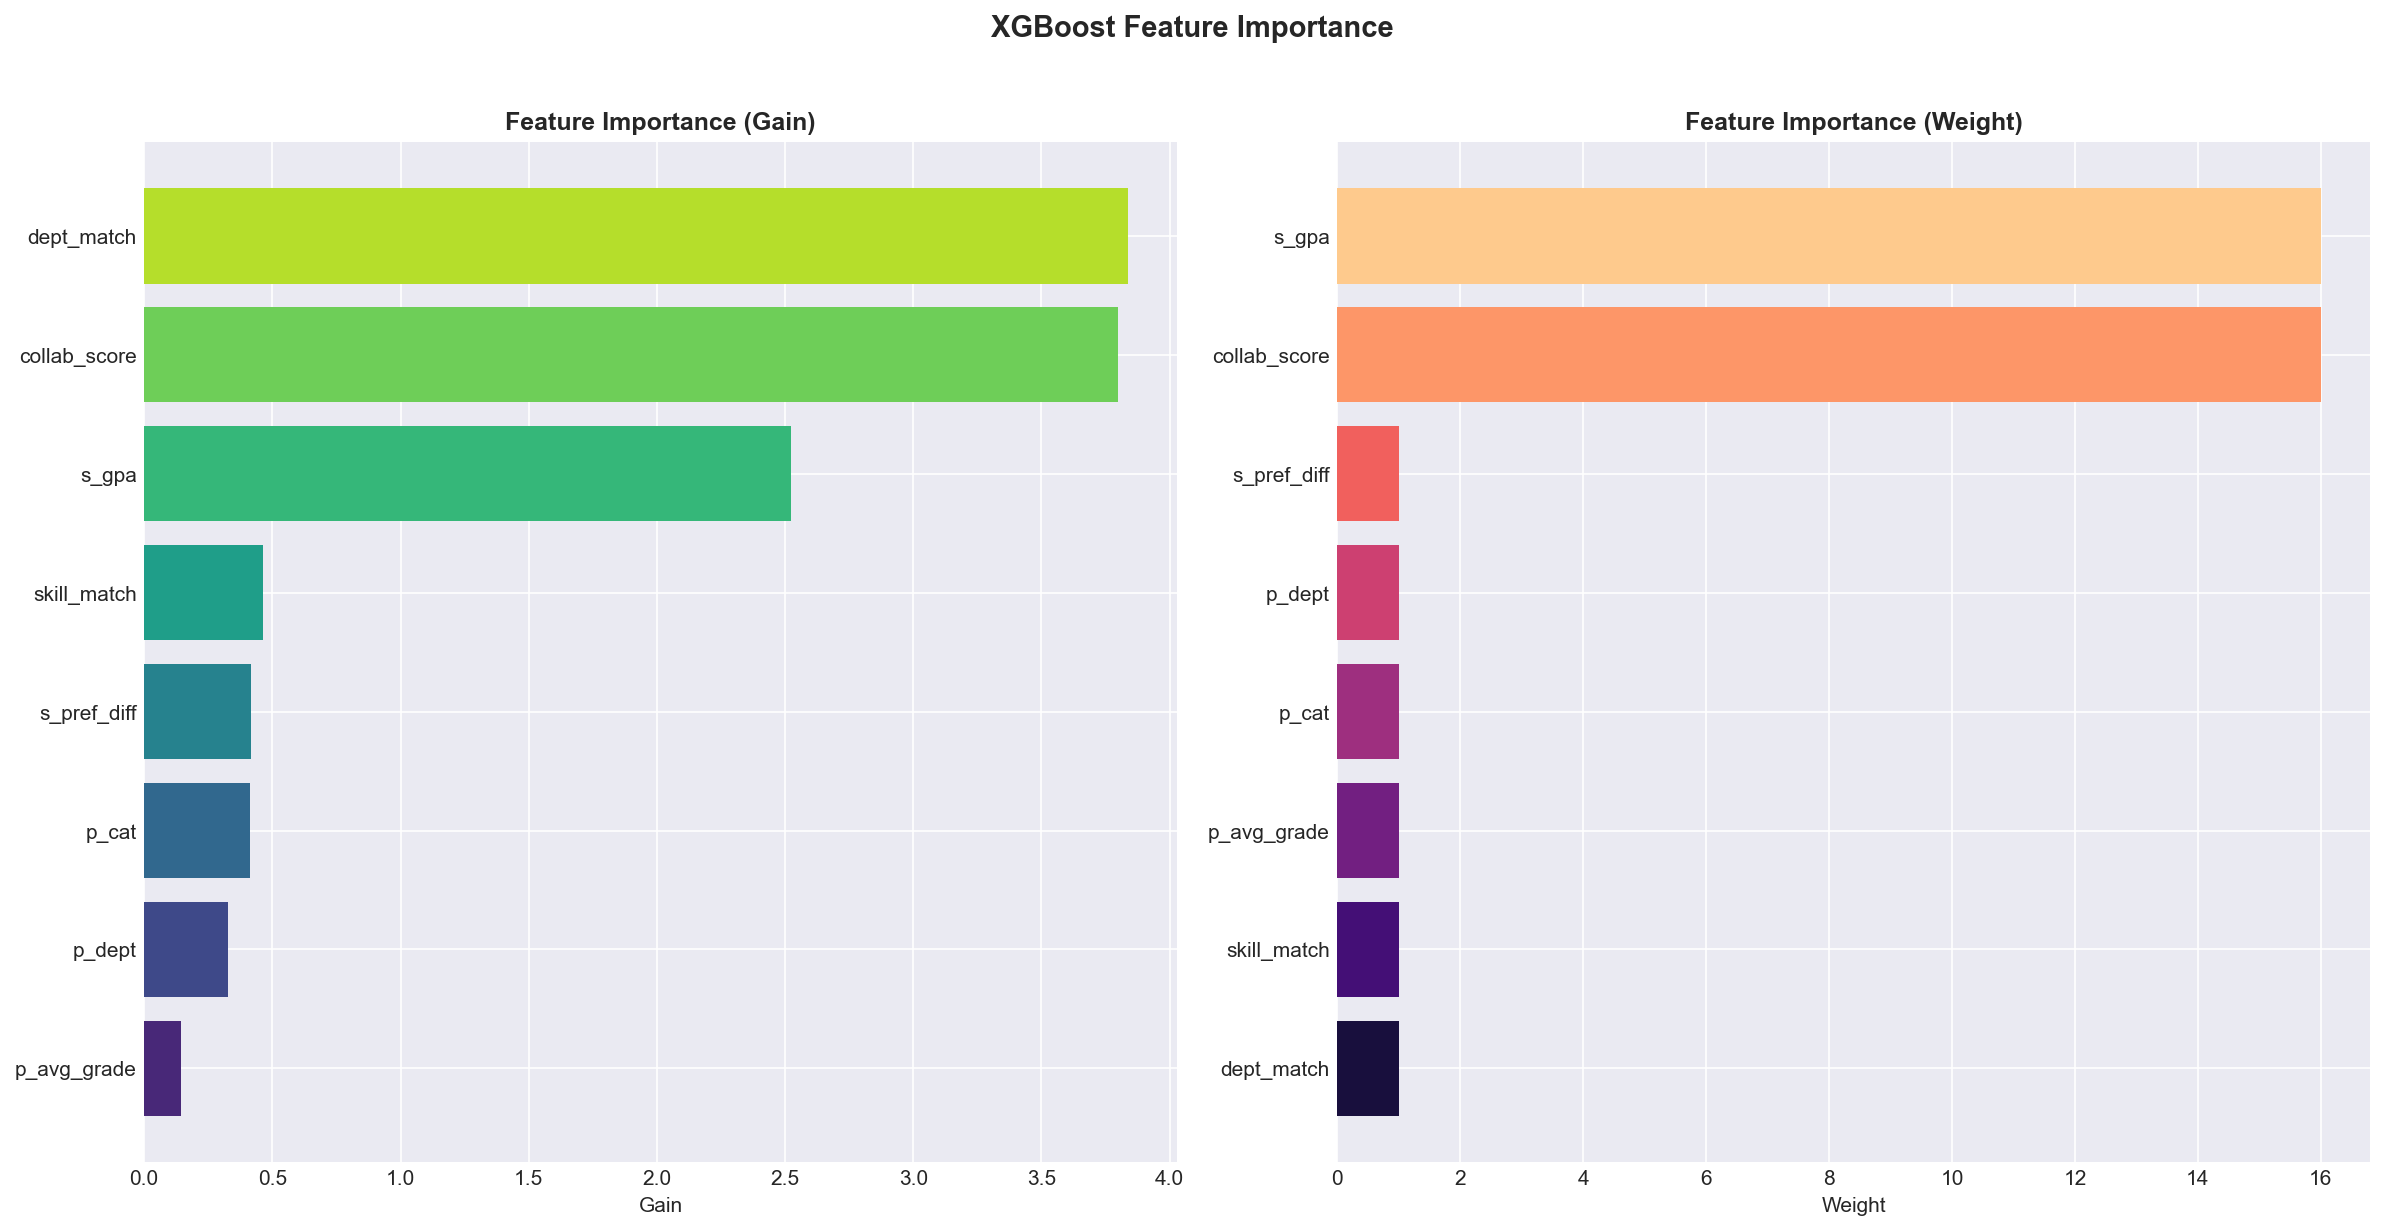

In [26]:
# Plot 10: Feature Importance
importance = model.get_score(importance_type='gain')
importance_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

feat_names = [f[0] for f in importance_sorted]
gain_values = [f[1] for f in importance_sorted]
colors = sns.color_palette("viridis", len(feat_names))
axes[0].barh(feat_names[::-1], gain_values[::-1], color=colors)
axes[0].set_title('Feature Importance (Gain)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gain')

importance_weight = model.get_score(importance_type='weight')
importance_weight_sorted = sorted(importance_weight.items(), key=lambda x: x[1], reverse=True)
feat_names_w = [f[0] for f in importance_weight_sorted]
weight_values = [f[1] for f in importance_weight_sorted]
axes[1].barh(feat_names_w[::-1], weight_values[::-1], color=sns.color_palette("magma", len(feat_names_w)))
axes[1].set_title('Feature Importance (Weight)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weight')

plt.suptitle('XGBoost Feature Importance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('10_feature_importance.png')

## 9. Hybrid Model

In [27]:
class HybridRecommender:
    def __init__(self, xgb_model, content_weight=0.25, collab_weight=0.20, 
                 ranker_weight=0.25, research_weight=0.15, tech_weight=0.15):
        self.model = xgb_model
        self.content_weight = content_weight
        self.collab_weight = collab_weight
        self.ranker_weight = ranker_weight
        self.research_weight = research_weight
        self.tech_weight = tech_weight

    def recommend(self, student_idx, top_n=5):
        # Get pre-computed scores
        c_scores = content_scores_all[student_idx]
        cf_scores = collab_scores_all[student_idx]
        r_scores = research_overlap_all[student_idx]
        t_scores = tech_similarity_all[student_idx]

        # Build features for ranker
        features_array = np.column_stack([
            np.full(n_projects, student_features_df[student_idx, 0]),
            np.full(n_projects, student_features_df[student_idx, 1]),
            np.full(n_projects, student_features_df[student_idx, 2]),
            np.full(n_projects, student_features_df[student_idx, 3]),
            np.full(n_projects, student_features_df[student_idx, 4]),
            np.full(n_projects, student_features_df[student_idx, 5]),
            project_features_df[:, 0],
            project_features_df[:, 1],
            project_features_df[:, 2],
            project_features_df[:, 3],
            project_features_df[:, 4],
            project_features_df[:, 5],
            skill_match_matrix[student_idx],
            dept_match_matrix[student_idx],
            diff_match_matrix[student_idx],
            c_scores,
            cf_scores,
            r_scores,
            t_scores,
            career_alignment_all[student_idx]
        ])

        dmatrix = xgb.DMatrix(features_array, feature_names=feature_names)
        ranker_scores = self.model.predict(dmatrix)
        ranker_scores = (ranker_scores - ranker_scores.min()) / (ranker_scores.max() - ranker_scores.min() + 1e-8)

        # Hybrid scores with research and tech weights
        hybrid_scores = (self.content_weight * c_scores +
                        self.collab_weight * cf_scores +
                        self.ranker_weight * ranker_scores +
                        self.research_weight * r_scores +
                        self.tech_weight * t_scores)

        top_indices = np.argsort(hybrid_scores)[-top_n:][::-1]
        results = [(idx, hybrid_scores[idx], c_scores[idx], cf_scores[idx],
                   ranker_scores[idx], r_scores[idx], t_scores[idx])
                for idx in top_indices]
        return results

recommender = HybridRecommender(model)

# Test
test_idx = 0
print(f"Student {test_idx}: {students.iloc[test_idx]['department']}, GPA: {students.iloc[test_idx]['gpa']}")
print(f"Interests: {students.iloc[test_idx]['interests']}")

recs = recommender.recommend(test_idx, top_n=5)
print(f"\nTop 5 Recommendations:")
for i, (proj_idx, score, c, cf, r, res, tech) in enumerate(recs):
    proj = projects.iloc[proj_idx]
    print(f"  {i+1}. {proj['title'][:70]}...")
    print(f"     Research: {proj['research_area']} | Difficulty: {proj['difficulty']}")
    print(f"     Hybrid: {score:.4f} (C: {c:.3f}, CF: {cf:.3f}, R: {r:.3f}, Res: {res:.3f}, Tech: {tech:.3f})")

IndentationError: unexpected indent (1894095059.py, line 72)

In [ ]:
# Plot 11: Recommendation Breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rec_titles = [f"Proj {i+1}" for i in range(5)]
content_vals = [r[2] for r in recs]
collab_vals = [r[3] for r in recs]
ranker_vals = [r[4] for r in recs]
research_vals = [r[5] for r in recs]
tech_vals = [r[6] for r in recs]

x = np.arange(5)
width = 0.15

axes[0].bar(x - 2*width, content_vals, width, label='Content', color='#3498db')
axes[0].bar(x - width, collab_vals, width, label='Collaborative', color='#e74c3c')
axes[0].bar(x, ranker_vals, width, label='Ranker', color='#2ecc71')
axes[0].bar(x + width, research_vals, width, label='Research', color='#f39c12')
axes[0].bar(x + 2*width, tech_vals, width, label='Tech', color='#9b59b6')
axes[0].set_xlabel('Recommendation')
axes[0].set_ylabel('Score')
axes[0].set_title('Score Breakdown', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rec_titles)
axes[0].legend()

# Weighted contributions
content_contrib = [c * recommender.content_weight for c in content_vals]
collab_contrib = [cf * recommender.collab_weight for cf in collab_vals]
ranker_contrib = [r * recommender.ranker_weight for r in ranker_vals]
research_contrib = [res * recommender.research_weight for res in research_vals]
tech_contrib = [tech * recommender.tech_weight for tech in tech_vals]

axes[1].bar(x, content_contrib, width, label='Content', color='#3498db')
axes[1].bar(x, collab_contrib, width, bottom=content_contrib, label='Collab', color='#e74c3c')
axes[1].bar(x, ranker_contrib, width,
            bottom=[a+b for a, b in zip(content_contrib, collab_contrib)],
            label='Ranker', color='#2ecc71')
axes[1].bar(x, research_contrib, width,
            bottom=[a+b+c for a, b, c in zip(content_contrib, collab_contrib, ranker_contrib)],
            label='Research', color='#f39c12')
axes[1].bar(x, tech_contrib, width,
            bottom=[a+b+c+d for a, b, c, d in zip(content_contrib, collab_contrib, ranker_contrib, research_contrib)],
            label='Tech', color='#9b59b6')
axes[1].set_xlabel('Recommendation')
axes[1].set_ylabel('Weighted Score')
axes[1].set_title('Hybrid Score Composition', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(rec_titles)
axes[1].legend()

plt.suptitle('Recommendation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('11_recommendation_breakdown.png')

## 10. Evaluation

In [ ]:
def evaluate_model(recommender, test_students, k=5):
    hits = 0
    total = 0
    reciprocal_ranks = []

    for student_idx in test_students[:50]:
        student_id = students.iloc[student_idx]['student_id']
        actual_projects = history[history['student_id'] == student_id]['project_id'].tolist()
        actual_project_ids = set(actual_projects)
        if not actual_project_ids:
            continue
        recs = recommender.recommend(student_idx, top_n=k)
        rec_project_ids = [projects.iloc[r[0]]['project_id'] for r in recs]
        for rank, proj_id in enumerate(rec_project_ids):
            if proj_id in actual_project_ids:
                hits += 1
                reciprocal_ranks.append(1.0 / (rank + 1))
                break
        total += 1

    return {
        'Precision@K': hits / total if total > 0 else 0,
        'Hit Rate@K': hits / total if total > 0 else 0,
        'MRR': np.mean(reciprocal_ranks) if reciprocal_ranks else 0
    }

metrics = evaluate_model(recommender, list(range(min(100, n_students))), k=5)
print("\nEvaluation Metrics:")
for metric, value in metrics.items():
    print(f"  {metric}: {value:.4f}")

In [ ]:
# Plot 12: Evaluation Summary
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metric_names = list(metrics.keys())
metric_values = list(metrics.values())
colors = ['#3498db', '#2ecc71', '#f39c12']
axes[0].bar(metric_names, metric_values, color=colors)
axes[0].set_title('Evaluation Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(metric_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Most recommended research areas
top_areas = []
for i in range(min(20, n_students)):
    recs = recommender.recommend(i, top_n=5)
    for r in recs:
        top_areas.append(projects.iloc[r[0]]['research_area'])

area_series = pd.Series(top_areas).value_counts().head(10)
axes[1].barh(area_series.index[::-1], area_series.values[::-1], color=sns.color_palette("viridis", 10))
axes[1].set_title('Most Recommended Research Areas', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

# Difficulty distribution
diff_dist = []
for i in range(min(20, n_students)):
    recs = recommender.recommend(i, top_n=5)
    for r in recs:
        diff_dist.append(projects.iloc[r[0]]['difficulty'])

diff_series = pd.Series(diff_dist).value_counts()
colors_diff = {'Easy': '#2ecc71', 'Medium': '#f39c12', 'Hard': '#e74c3c'}
axes[2].pie(diff_series.values, labels=diff_series.index, autopct='%1.1f%%',
            colors=[colors_diff.get(x, '#95a5a6') for x in diff_series.index])
axes[2].set_title('Recommended Difficulty Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Model Evaluation Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('12_evaluation_summary.png')

## 11. Save Model Artifacts

In [ ]:
import pickle

model.save_model(r"C:\kb\student project\model\xgboost_ranker.json")

with open(r"C:\kb\student project\model\encoders.pkl", 'wb') as f:
    pickle.dump({
        'dept_encoder': dept_encoder,
        'cat_encoder': cat_encoder,
        'research_area_encoder': research_area_encoder,
        'interest_vectorizer': interest_vectorizer,
        'project_vectorizer': project_vectorizer,
        'research_tag_vectorizer': research_tag_vectorizer,
        'scaler': scaler,
        'feature_names': feature_names
    }, f)

np.save(r"C:\kb\student project\model\student_factors.npy", student_factors)
np.save(r"C:\kb\student project\model\project_factors.npy", project_factors)
np.save(r"C:\kb\student project\model\content_scores_all.npy", content_scores_all)
np.save(r"C:\kb\student project\model\collab_scores_all.npy", collab_scores_all)
np.save(r"C:\kb\student project\model\research_overlap_all.npy", research_overlap_all)
np.save(r"C:\kb\student project\model\tech_similarity_all.npy", tech_similarity_all)
np.save(r"C:\kb\student project\model\career_alignment_all.npy", career_alignment_all)
np.save(r"C:\kb\student project\model\skill_match_matrix.npy", skill_match_matrix)
np.save(r"C:\kb\student project\model\dept_match_matrix.npy", dept_match_matrix)
np.save(r"C:\kb\student project\model\diff_match_matrix.npy", diff_match_matrix)

print("Model artifacts saved!")
print(f"  Model: C:\\kb\\student project\\model\\xgboost_ranker.json")
print(f"  Plots: C:\\kb\\student project\\plots\\ (12 files)")

## Summary

### New Features Added

| Feature | Description |
|---------|-------------|
| `research_area` | Major research area for each project |
| `research_tags` | Related tags for research matching |
| `research_overlap` | Jaccard similarity between student interests and project tags |
| `tech_similarity` | Tech stack compatibility score |
| `career_alignment` | Career path alignment based on dept, GPA, difficulty |

### Visualizations Generated (12 plots)

| # | Filename | Description |
|---|----------|-------------|
| 1 | 01_dataset_overview.png | Students/Projects/Difficulty distribution |
| 2 | 02_research_areas.png | Research area distribution and difficulty |
| 3 | 03_student_demographics.png | GPA, Year level, Department analysis |
| 4 | 04_wordclouds.png | Project titles and Research tags |
| 5 | 05_history_analysis.png | Grades, Completion, Ratings, Semesters |
| 6 | 06_similarity_distributions.png | All similarity score distributions |
| 7 | 07_feature_distributions.png | Feature value histograms |
| 8 | 08_feature_correlations_target.png | Feature-Target correlations |
| 9 | 09_xgboost_training.png | Training NDCG and loss curves |
| 10 | 10_feature_importance.png | XGBoost feature importance |
| 11 | 11_recommendation_breakdown.png | Score composition analysis |
| 12 | 12_evaluation_summary.png | Precision, Hit Rate, MRR |

### Hybrid Model Weights

| Component | Weight |
|-----------|--------|
| Content-Based | 0.25 |
| Collaborative | 0.20 |
| XGBoost Ranker | 0.25 |
| Research Overlap | 0.15 |
| Tech Similarity | 0.15 |